## Whole-tumor segmentation
### Assignment 2
Student: Indira Duisembayeva
Student ID: 25011125

### Setup to access 

In [2]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
from pathlib import Path
import copy
import hashlib
import importlib.metadata
import itertools
import json
import platform
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import nibabel as nib
from nibabel.processing import resample_from_to, resample_to_output
from scipy import ndimage
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from IPython.display import display, Markdown


In [21]:
DATA_ROOT = Path("Task01_BrainTumour")
split_df = pd.read_csv(DATA_ROOT / "assignment2_split.csv")
assert len(split_df) == 484
assert set(split_df["split"]) == {"train", "validation", "test"}
for row in split_df.itertuples():
    assert (DATA_ROOT / row.image_relpath).exists()
    assert (DATA_ROOT / row.label_relpath).exists()
print(split_df["split"].value_counts())

split
train         338
test           73
validation     73
Name: count, dtype: int64


In [22]:
SEED = 42
PATCH_SIZE = (64, 64, 64)  # D, H, W
BASE_CHANNELS = 8
BATCH_SIZE = 2
EPOCHS = 10
STEPS_PER_EPOCH = 100
LEARNING_RATE = 1e-3
TUMOR_PROBABILITY = 0.5
OVERLAP = 0.5
THRESHOLD = 0.5
MIN_COMPONENT_ML = 0.10 
TARGET_SPACING = (1.0, 1.0, 1.0)
CHANNELS = ['FLAIR', 'T1', 'T1ce', 'T2']

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_DIR = Path('local_run')
CACHE_DIR = RUN_DIR / 'cache'
FIG_DIR = RUN_DIR / 'figures'
TABLE_DIR = RUN_DIR / 'tables'
PROB_DIR = RUN_DIR / 'probabilities'
for folder in [CACHE_DIR, FIG_DIR, TABLE_DIR, PROB_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
NOTEBOOK_START = time.perf_counter()


In [23]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)


def save_figure(name):
    plt.savefig(FIG_DIR / f'{name}.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close()


def save_table(table, name):
    table.to_csv(TABLE_DIR / f'{name}.csv', index=False)
    display(table)


# Task A:

The input for thismodel wiil be four co-registered 3D MRI channels from one patient case: FLAIR, T1, T1ce and T2. As an output, model will produce one binary 3D whole-tumor mask on a documented physical grid. The intended technical use if this model is study patch sampling and reconstruction for automated research segmentation for study reasons. 

 **Voxel** is one small 3D element with a physical size. A **slice** is a 2D section of a volume.
A **volume** is a complete 3D image. A **patient case** contains the four aligned volumes and reference
labels for that patient. A patch is only a small training sample from a volume, not an independent patient.


In [24]:
with open(DATA_ROOT / "dataset.json") as file:    dataset_info = json.load(file)

channel_order = [ dataset_info["modality"][str(i)] for i in range(4)]
case_ids = ["BRATS_001", "BRATS_003", "BRATS_004"]

loaded_cases = {}
geometry_rows = []

for case_id in case_ids:
    image = nib.load(DATA_ROOT / "imagesTr" / f"{case_id}.nii.gz")
    label = nib.load(DATA_ROOT / "labelsTr" / f"{case_id}.nii.gz")

    # The four channels share one spatial grid in the 4D MRI file.
    assert len(image.shape) == 4 and image.shape[-1] == 4
    assert image.shape[:3] == label.shape
    assert np.allclose(image.affine, label.affine)
    assert image.header.get_xyzt_units()[0] == "mm"
    assert label.header.get_xyzt_units()[0] == "mm"

    label_values = np.unique(np.asarray(label.dataobj)).astype(int)
    geometry_rows.append({
        "Case": case_id,
        "MRI shape (X, Y, Z, C)": image.shape,
        "Label shape (X, Y, Z)": label.shape,
        "Channel order": ", ".join(channel_order),
        "MRI orientation": "".join(nib.aff2axcodes(image.affine)),
        "Label orientation": "".join(nib.aff2axcodes(label.affine)),
        "MRI spacing (mm)": tuple(nib.affines.voxel_sizes(image.affine)),
        "Label spacing (mm)": tuple(nib.affines.voxel_sizes(label.affine)),
        "Label values": label_values.tolist(),
    })
    loaded_cases[case_id] = (image, label)

    print(f"\n{case_id}")
    print("MRI affine:")
    print(image.affine)
    print("Label affine:")
    print(label.affine)

geometry_table = pd.DataFrame(geometry_rows)
display(geometry_table)


BRATS_001
MRI affine:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
Label affine:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

BRATS_003
MRI affine:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
Label affine:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

BRATS_004
MRI affine:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
Label affine:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


,Case,"MRI shape (X, Y, Z, C)","Label shape (X, Y, Z)",Channel order,MRI orientation,Label orientation,MRI spacing (mm),Label spacing (mm),Label values
0,BRATS_001,"(240, 240, 155, 4)","(240, 240, 155)","FLAIR, T1w, t1gd, T2w",RAS,RAS,"(1.0, 1.0, 1.0)","(1.0, 1.0, 1.0)","[0, 1, 2, 3]"
1,BRATS_003,"(240, 240, 155, 4)","(240, 240, 155)","FLAIR, T1w, t1gd, T2w",RAS,RAS,"(1.0, 1.0, 1.0)","(1.0, 1.0, 1.0)","[0, 1, 2, 3]"
2,BRATS_004,"(240, 240, 155, 4)","(240, 240, 155)","FLAIR, T1w, t1gd, T2w",RAS,RAS,"(1.0, 1.0, 1.0)","(1.0, 1.0, 1.0)","[0, 1, 2, 3]"


Selected voxel (X, Y, Z): (157, 116, 67)
Physical location (R, A, S), mm: [157. 116.  67.]


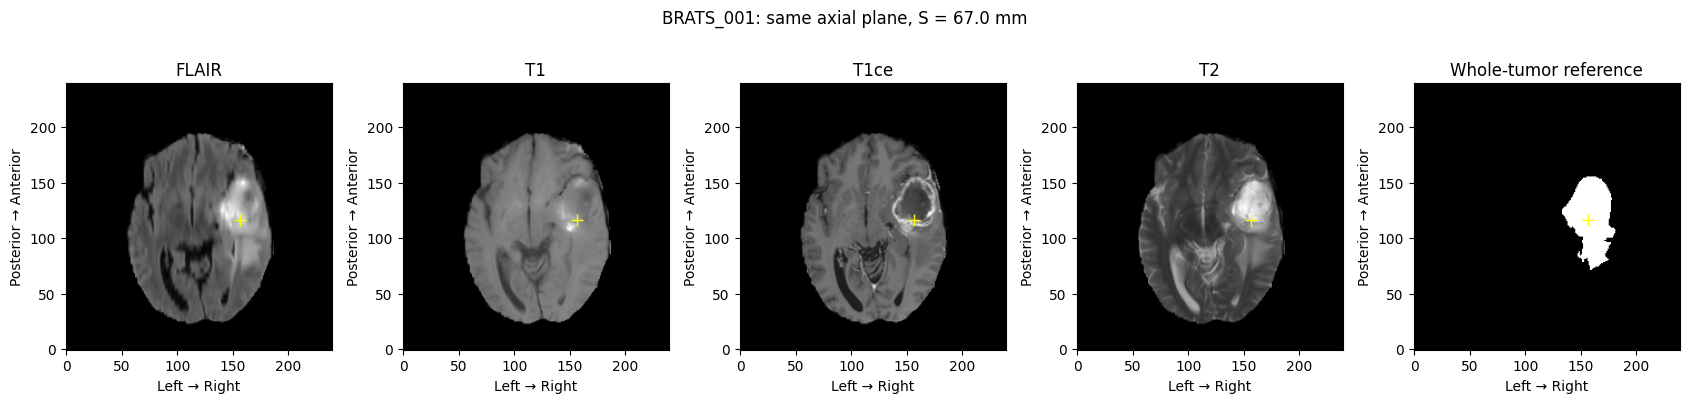

In [25]:
case_id = case_ids[0]
image, label = loaded_cases[case_id]

#flip axes consistently to RAS+.
image_ras = nib.as_closest_canonical(image, enforce_diag=True)
label_ras = nib.as_closest_canonical(label, enforce_diag=True)
assert image_ras.shape[:3] == label_ras.shape
assert np.allclose(image_ras.affine, label_ras.affine)

mri = image_ras.get_fdata(dtype=np.float32)
original_labels = np.asarray(label_ras.dataobj)
whole_tumor = original_labels > 0

#choose a tumor voxel close to the tumors centre.
tumor_voxels = np.argwhere(whole_tumor)
assert len(tumor_voxels) > 0, "The selected case has no reference tumor."

centre = tumor_voxels.mean(axis=0)
distances = np.sum((tumor_voxels - centre) ** 2, axis=1)
x, y, z = tumor_voxels[np.argmin(distances)]

world_position = nib.affines.apply_affine(image_ras.affine, [x, y, z])

sx, sy, sz = nib.affines.voxel_sizes(image_ras.affine)

print("Selected voxel (X, Y, Z):", (x, y, z))
print("Physical location (R, A, S), mm:", np.round(world_position, 2))
display_names = {
    "flair": "FLAIR",
    "t1w": "T1",
    "t1gd": "T1ce",
    "t2w": "T2",
}

fig, axes = plt.subplots(1, 5, figsize=(17, 4))

for channel in range(4):
    axes[channel].imshow(mri[:, :, z, channel].T,cmap="gray",origin="lower",aspect=sy / sx,)
    axes[channel].set_title(display_names[channel_order[channel].lower()])

axes[4].imshow(whole_tumor[:, :, z].T, cmap="gray", origin="lower", aspect=sy / sx, vmin=0, vmax=1,)
axes[4].set_title("Whole-tumor reference")

for ax in axes:
    ax.plot(x, y, "+", color="yellow", markersize=9)
    ax.set_xlabel("Left → Right")
    ax.set_ylabel("Posterior → Anterior")

fig.suptitle(
    f"{case_id}: same axial plane, "
    f"S = {world_position[2]:.1f} mm"
)
plt.tight_layout()
plt.show()

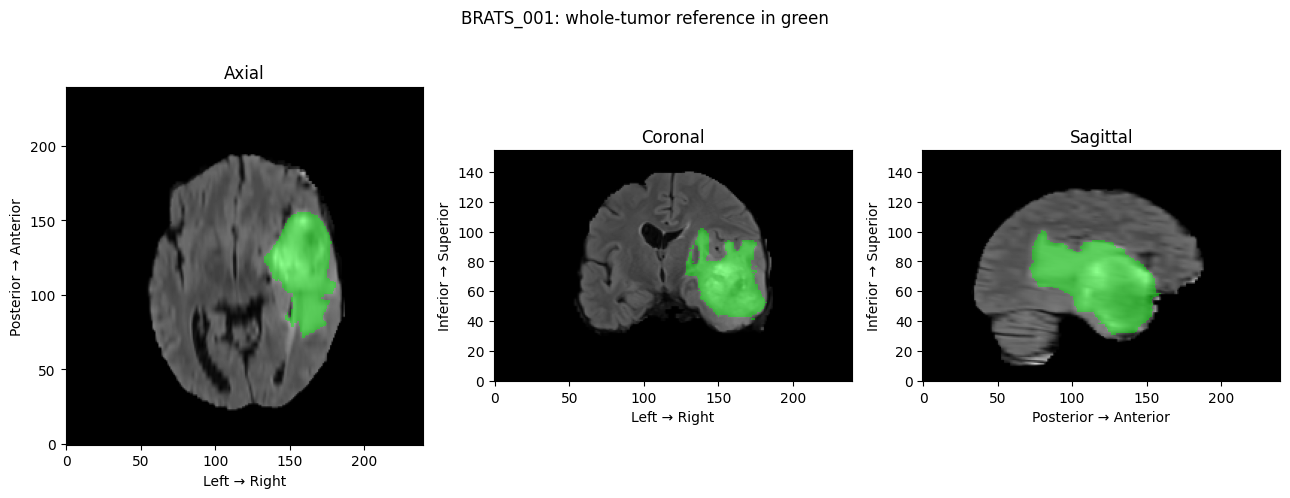

In [26]:
flair_index = [ name.lower() for name in channel_order].index("flair")

flair = mri[..., flair_index]

# MRI slice, matching reference slice, physical pixel aspect, directions
planes = [
    (
        "Axial",
        flair[:, :, z].T,
        whole_tumor[:, :, z].T,
        sy / sx,
        "Left → Right",
        "Posterior → Anterior",
    ),
    (
        "Coronal",
        flair[:, y, :].T,
        whole_tumor[:, y, :].T,
        sz / sx,
        "Left → Right",
        "Inferior → Superior",
    ),
    (
        "Sagittal",
        flair[x, :, :].T,
        whole_tumor[x, :, :].T,
        sz / sy,
        "Posterior → Anterior",
        "Inferior → Superior",
    ),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, (name, mri_slice, mask_slice, aspect, xlabel, ylabel) in zip(axes, planes):
    ax.imshow( mri_slice, cmap="gray", origin="lower", aspect=aspect,)
    overlay = np.ma.masked_where(~mask_slice, mask_slice)

    ax.imshow( overlay, cmap=ListedColormap(["lime"]), alpha=0.45, origin="lower", aspect=aspect, vmin=0, vmax=1, interpolation="nearest",)
    ax.set_title(name)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

fig.suptitle(f"{case_id}: whole-tumor reference in green")
plt.tight_layout()
plt.show()

# Task B

Case counts are reported for all splits. Reference tumor-volume distributions are calculated for training and validation during development. The test distribution is calculated only during final evaluation to preserve the held-out test labels.

In [27]:
def read_split(root):
    split_path = root / "assignment2_split.csv"
    table = pd.read_csv(split_path, dtype=str, keep_default_na=False)
    assert set(table["split"]) == { "train", "validation", "test"}, "Expected train, validation and test splits."

    assert (table["case_id"] != "").all(), "Empty case ID found."
    assert table["case_id"].is_unique, "Repeated case IDs found."

    table["image"] = [
        (root / path).resolve()
        for path in table["image_relpath"]
    ]
    table["label"] = [
        (root / path).resolve()
        for path in table["label_relpath"]
    ]

    for row in table.itertuples():
        assert row.image.is_file(), f"Missing image: {row.image}"
        assert row.label.is_file(), f"Missing label: {row.label}"

    assert table["image"].is_unique, "Repeated image paths found."
    assert table["label"].is_unique, "Repeated label paths found."

    return table, split_path

In [28]:
cases, split_path = read_split(DATA_ROOT)
split_hash = hashlib.sha256(split_path.read_bytes()).hexdigest()

train_rows = cases[cases.split == 'train'].reset_index(drop=True)
val_rows = cases[cases.split == 'validation'].reset_index(drop=True)
test_rows = cases[cases.split == 'test'].reset_index(drop=True)

In [29]:
def reference_volume_table(rows):
    records = []

    for row in rows.itertuples():
        label = nib.load(row.label)
        assert label.header.get_xyzt_units()[0] == "mm"

        mask = np.asarray(label.dataobj) > 0
        spacing = nib.affines.voxel_sizes(label.affine)

        # mm³ to mL: divide by 1,000.
        volume_ml = np.count_nonzero(mask) * np.prod(spacing) / 1000

        records.append({
            "case_id": row.case_id,
            "split": row.split,
            "tumor_volume_ml": volume_ml,
        })

    return pd.DataFrame(records)


development_volumes = reference_volume_table(
    pd.concat([train_rows, val_rows], ignore_index=True)
)

volume_summary = (
    development_volumes.groupby("split")["tumor_volume_ml"]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .round(2)
)

display(volume_summary)


,count,mean,std,median,min,max
split,,,,,,
train,338,102.96,56.96,95.48,8.48,265.25
validation,73,100.76,62.95,91.56,7.28,266.94


In [30]:
split_counts = ( cases.groupby("split").size().reset_index(name="cases"))
save_table(split_counts, "split_counts")
print("Split file:", split_path.name)
print("SHA256:", split_hash)

channel_names = {
    "FLAIR": "FLAIR",
    "T1w": "T1",
    "t1gd": "T1ce",
    "T2w": "T2",
}

file_channels = [channel_names[name] for name in channel_order]
assert len(file_channels) == 4
assert set(file_channels) == set(CHANNELS)

channel_indices = [file_channels.index(name) for name in CHANNELS]

allowed_labels = {int(value) for value in dataset_info["labels"]}
print("File channel order:", channel_order)
print("Model channel order:", CHANNELS)
print("Allowed label values:", sorted(allowed_labels))


,split,cases
0,test,73
1,train,338
2,validation,73


Split file: assignment2_split.csv
SHA256: ab1678f0ee48b99e13d42f4c3d55f6a6a36ee930704a46b9da7739b7541aea30
File channel order: ['FLAIR', 'T1w', 't1gd', 'T2w']
Model channel order: ['FLAIR', 'T1', 'T1ce', 'T2']
Allowed label values: [0, 1, 2, 3]


# Part C:


In [31]:
from nibabel.processing import resample_from_to, resample_to_output

def same_grid(image, shape, affine):
    return (image.shape[:3] == tuple(shape) and np.allclose(image.affine, affine, atol=1e-5, rtol=0))

geometry_records = []

# We keep test labels unopened.
development_rows = pd.concat([train_rows, val_rows], ignore_index=True)

for row in development_rows.itertuples():
    image = nib.load(row.image)
    label = nib.load(row.label)

    assert len(image.shape) == 4 and image.shape[-1] == 4
    assert len(label.shape) == 3
    assert image.header.get_xyzt_units()[0] == "mm"
    assert label.header.get_xyzt_units()[0] == "mm"

    geometry_records.append({
        "case_id": row.case_id,
        "MRI_shape": image.shape,
        "label_shape": label.shape,
        "MRI_orientation": "".join(nib.aff2axcodes(image.affine)),
        "label_orientation": "".join(nib.aff2axcodes(label.affine)),
        "MRI_spacing_mm": tuple(nib.affines.voxel_sizes(image.affine)),
        "label_spacing_mm": tuple(nib.affines.voxel_sizes(label.affine)),
        "image_label_same_grid": same_grid(
            image, label.shape, label.affine
        ),
    })

geometry_report = pd.DataFrame(geometry_records)

display(geometry_report.head())
print("Development cases checked:", len(geometry_report))
print(
    "Cases with different image/label grids:",
    int((~geometry_report["image_label_same_grid"]).sum())
)

,case_id,MRI_shape,label_shape,MRI_orientation,label_orientation,MRI_spacing_mm,label_spacing_mm,image_label_same_grid
0,BRATS_001,"(240, 240, 155, 4)","(240, 240, 155)",RAS,RAS,"(1.0, 1.0, 1.0)","(1.0, 1.0, 1.0)",True
1,BRATS_003,"(240, 240, 155, 4)","(240, 240, 155)",RAS,RAS,"(1.0, 1.0, 1.0)","(1.0, 1.0, 1.0)",True
2,BRATS_004,"(240, 240, 155, 4)","(240, 240, 155)",RAS,RAS,"(1.0, 1.0, 1.0)","(1.0, 1.0, 1.0)",True
3,BRATS_005,"(240, 240, 155, 4)","(240, 240, 155)",RAS,RAS,"(1.0, 1.0, 1.0)","(1.0, 1.0, 1.0)",True
4,BRATS_007,"(240, 240, 155, 4)","(240, 240, 155)",RAS,RAS,"(1.0, 1.0, 1.0)","(1.0, 1.0, 1.0)",True


Development cases checked: 411
Cases with different image/label grids: 0


Each case uses one target grid: an axis-aligned RAS+ grid with 1 mm isotropic spacing covering the first MRI channel’s field of view. All four channels and the reference label are mapped to this same shape and affine. Matching grids are retained without interpolation. When resampling is necessary, MRI uses linear interpolation and labels use nearest-neighbour interpolation. Resampling changes the sampling grid; it does not correct anatomical misregistration.

In [32]:
def preprocess_case(row):
    image = nib.load(row.image)
    label = nib.load(row.label)

    assert len(image.shape) == 4 and image.shape[-1] == 4
    assert len(label.shape) == 3
    assert image.header.get_xyzt_units()[0] == "mm"
    assert label.header.get_xyzt_units()[0] == "mm"

    first_channel = nib.Nifti1Image( np.asarray( image.dataobj[..., channel_indices[0]], dtype=np.float32), image.affine,)

    target_image = resample_to_output(first_channel, voxel_sizes=TARGET_SPACING, order=1,)
    target = (target_image.shape, target_image.affine)

    channels = []
    statistics = []

    for name, index in zip(CHANNELS, channel_indices):
        channel = nib.Nifti1Image( np.asarray(image.dataobj[..., index], dtype=np.float32), image.affine,)
        if not same_grid(channel, *target):
            channel = resample_from_to(channel, target, order=1)

        values = channel.get_fdata(dtype=np.float32).copy()
        assert np.isfinite(values).all()

        brain = values != 0
        assert brain.any(), f"{row.case_id}: empty {name} channel"

        mean = values[brain].mean()
        std = values[brain].std()
        assert std > 1e-8, f"{row.case_id}: constant {name} channel"

        values[brain] = (values[brain] - mean) / std

        statistics.append({
            "case_id": row.case_id,
            "channel": name,
            "normalized_mean": float(values[brain].mean()),
            "normalized_std": float(values[brain].std()),
        })

        assert abs(statistics[-1]["normalized_mean"]) < 1e-4
        assert abs(statistics[-1]["normalized_std"] - 1) < 1e-4
        assert np.all(values[~brain] == 0)
        channels.append(values.transpose(2, 1, 0))
    original = label.get_fdata(dtype=np.float32)
    assert np.isfinite(original).all()
    assert np.allclose(original, np.rint(original))

    original_values = set(np.unique(original).astype(int))
    assert original_values.issubset(allowed_labels)

    if not same_grid(label, *target):
        label = resample_from_to(label, target, order=0)

    multiclass = label.get_fdata(dtype=np.float32)
    assert np.isfinite(multiclass).all()
    assert np.allclose(multiclass, np.rint(multiclass))

    new_values = set(np.unique(multiclass).astype(int))
    assert new_values.issubset(original_values | {0})
    assert new_values.issubset(allowed_labels)

    x = np.stack(channels).astype(np.float32)
    y = (multiclass > 0).transpose(2, 1, 0)[None].astype(np.float32)
    original_shape = y.shape[1:]

    padded_shape = [ int(np.ceil(max(n, p) / 4) * 4)  for n, p in zip(original_shape, PATCH_SIZE)]
    padding = [ (0, new - old) for old, new in zip(original_shape, padded_shape)]

    x = np.pad(x, [(0, 0)] + padding)
    y = np.pad(y, [(0, 0)] + padding)
    metadata = {
        "case_id": row.case_id,
        "affine_XYZ": target_image.affine,
        "spacing_DHW": nib.affines.voxel_sizes(
            target_image.affine
        )[::-1],
        "original_shape_DHW": original_shape,
        "padding_DHW": padding,
        "original_label_values": sorted(original_values),
        "resampled_label_values": sorted(new_values),
    }

    return x, y, metadata, statistics

Normalization uses each channel’s non-zero voxels before normalization, excluding zero-padded background. For these preprocessed brain images, this provides the foreground support for calculating the mean and standard deviation. The background remains zero.
I retain the full field of view and apply identical high-end padding to the MRI and mask. This preserves their alignment and leaves the target affine’s origin unchanged. The original target-grid shape is recorded so that padding can be removed after inference. Original NIfTI files are never modified.

In [33]:
normalization_records = []
label_records = []

for i, row in enumerate(train_rows.iloc[:3].itertuples()):
    x, y, metadata, statistics = preprocess_case(row)

    normalization_records.extend(statistics)
    label_records.append({
        "case_id": row.case_id,
        "labels_before": metadata["original_label_values"],
        "labels_after_resampling": metadata["resampled_label_values"],
        "binary_labels": np.unique(y).tolist(),
    })

    if i == 0:
        example_x = x
        example_y = y
        example_metadata = metadata

print("Label checks:")
display(pd.DataFrame(label_records))

print("Statistics on the original non-zero support after normalization:")
display(pd.DataFrame(normalization_records).round(6))

print("Image shape [C, D, H, W]:", example_x.shape)
print("Mask shape [1, D, H, W]:", example_y.shape)
print("Shape before padding:", example_metadata["original_shape_DHW"])
print("Padding:", example_metadata["padding_DHW"])
print("Target affine:")
print(example_metadata["affine_XYZ"])

Label checks:


,case_id,labels_before,labels_after_resampling,binary_labels
0,BRATS_001,"[0, 1, 2, 3]","[0, 1, 2, 3]","[0.0, 1.0]"
1,BRATS_003,"[0, 1, 2, 3]","[0, 1, 2, 3]","[0.0, 1.0]"
2,BRATS_004,"[0, 1, 2, 3]","[0, 1, 2, 3]","[0.0, 1.0]"


Statistics on the original non-zero support after normalization:


,case_id,channel,normalized_mean,normalized_std
0,BRATS_001,FLAIR,-0.000000,1.0
1,BRATS_001,T1,-0.000001,1.0
2,BRATS_001,T1ce,-0.000000,1.0
3,BRATS_001,T2,-0.000000,1.0
4,BRATS_003,FLAIR,0.000000,1.0
5,BRATS_003,T1,0.000001,1.0
6,BRATS_003,T1ce,-0.000000,1.0
7,BRATS_003,T2,-0.000000,1.0
8,BRATS_004,FLAIR,-0.000000,1.0
9,BRATS_004,T1,0.000001,1.0


Image shape [C, D, H, W]: (4, 156, 240, 240)
Mask shape [1, D, H, W]: (1, 156, 240, 240)
Shape before padding: (155, 240, 240)
Padding: [(0, 1), (0, 0), (0, 0)]
Target affine:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


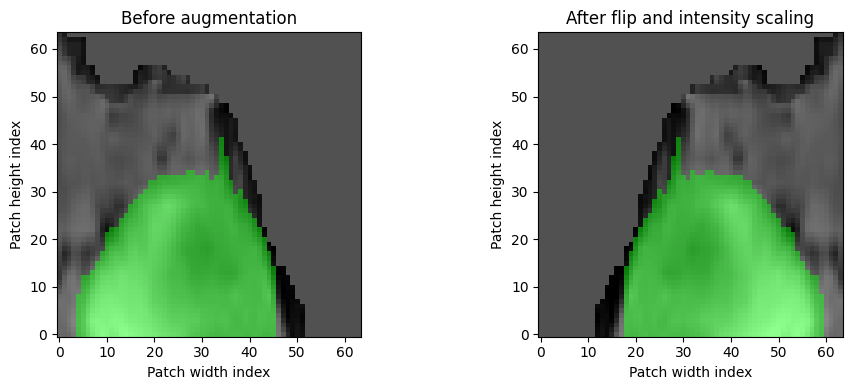

In [34]:
def augment_pair(x, y, rng, training=False, force_flip=False):
    x, y = x.copy(), y.copy()

    if training:
        if force_flip or rng.random() < 0.5:
            x = np.flip(x, axis=-1)
            y = np.flip(y, axis=-1)
        scales = rng.uniform( 0.9, 1.1, size=(4, 1, 1, 1) ).astype(np.float32)
        x = x * scales

    return np.ascontiguousarray(x), np.ascontiguousarray(y)

tumor_voxels = np.argwhere(example_y[0] > 0)
assert len(tumor_voxels) > 0

centre = tumor_voxels[len(tumor_voxels) // 2]
patch_size = np.array(PATCH_SIZE)
volume_shape = np.array(example_y.shape[1:])

start = np.clip( centre - patch_size // 2, 0, volume_shape - patch_size,)
region = tuple(slice(int(s), int(s + p)) for s, p in zip(start, patch_size))

before_x = example_x[(slice(None),) + region]
before_y = example_y[(slice(None),) + region]
after_x, after_y = augment_pair( before_x, before_y,  rng=np.random.default_rng(SEED), training=True, force_flip=True, )

assert np.array_equal(after_y, before_y[..., ::-1])
d = int(np.argmax(before_y[0].sum(axis=(1, 2))))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, image, mask, title in zip( axes, [before_x, after_x], [before_y, after_y], ["Before augmentation", "After flip and intensity scaling"], ):
    ax.imshow(image[0, d], cmap="gray", origin="lower", vmin=before_x[0, d].min(),  vmax=before_x[0, d].max(),)
    overlay = np.ma.masked_where( mask[0, d] == 0, mask[0, d], )

    ax.imshow( overlay, cmap=ListedColormap(["lime"]), origin="lower", alpha=0.45, vmin=0, vmax=1, interpolation="nearest",)
    ax.set_title(title)
    ax.set_xlabel("Patch width index")
    ax.set_ylabel("Patch height index")

plt.tight_layout()
save_figure("C_paired_augmentation")

Augmentation is applied only to training patches. The left–right flip is applied identically to all MRI channels and the mask, preserving their alignment. It is appropriate for this whole-tumor segmentation task because laterality is not the prediction target. Small intensity scaling between 0.9 and 1.1 introduces modest contrast variation while preserving zero background. Labels are not intensity-scaled or interpolated during augmentation. Validation and test data receive only deterministic preprocessing.

# Part D


In [35]:
# Caching all training and validation cases using the Part C function.

def cache_cases(rows):
    for i, row in enumerate(rows.itertuples(), start=1):
        x, y, metadata, _ = preprocess_case(row)

        folder = CACHE_DIR / row.case_id
        folder.mkdir(parents=True, exist_ok=True)
        np.save(folder / "image.npy", x)
        np.save(folder / "mask.npy", y.astype(np.uint8))
        np.save(folder / "tumor_indices.npy", np.flatnonzero(y[0]))

        geometry = {
            "original_shape_DHW": list(metadata["original_shape_DHW"]),
            "affine_XYZ": np.asarray(metadata["affine_XYZ"]).tolist(),
            "spacing_DHW": np.asarray(metadata["spacing_DHW"]).tolist(),
        }
        (folder / "geometry.json").write_text(json.dumps(geometry, indent=2) )

        print(f"Cached {i}/{len(rows)}: {row.case_id}", flush=True)
cache_cases(development_rows)

Cached 1/411: BRATS_001
Cached 2/411: BRATS_003
Cached 3/411: BRATS_004
Cached 4/411: BRATS_005
Cached 5/411: BRATS_007
Cached 6/411: BRATS_008
Cached 7/411: BRATS_009
Cached 8/411: BRATS_010
Cached 9/411: BRATS_011
Cached 10/411: BRATS_013
Cached 11/411: BRATS_014
Cached 12/411: BRATS_015
Cached 13/411: BRATS_017
Cached 14/411: BRATS_018
Cached 15/411: BRATS_021
Cached 16/411: BRATS_022
Cached 17/411: BRATS_024
Cached 18/411: BRATS_025
Cached 19/411: BRATS_026
Cached 20/411: BRATS_027
Cached 21/411: BRATS_029
Cached 22/411: BRATS_030
Cached 23/411: BRATS_032
Cached 24/411: BRATS_034
Cached 25/411: BRATS_035
Cached 26/411: BRATS_036
Cached 27/411: BRATS_037
Cached 28/411: BRATS_038
Cached 29/411: BRATS_040
Cached 30/411: BRATS_042
Cached 31/411: BRATS_043
Cached 32/411: BRATS_044
Cached 33/411: BRATS_045
Cached 34/411: BRATS_046
Cached 35/411: BRATS_047
Cached 36/411: BRATS_048
Cached 37/411: BRATS_049
Cached 38/411: BRATS_051
Cached 39/411: BRATS_052
Cached 40/411: BRATS_053
Cached 41

In [36]:
# Implementing dataset and DataLoader.
class TumorPatchDataset(Dataset):
    def __init__(self, rows, tumor_probability):
        self.case_ids = rows["case_id"].tolist()
        self.tumor_probability = tumor_probability
        self.epoch = 0

    def __len__(self):
        return STEPS_PER_EPOCH * BATCH_SIZE

    def __getitem__(self, index):
        base_seed = SEED + self.epoch * len(self) + index
        case_rng = np.random.default_rng(base_seed)
        patch_rng = np.random.default_rng(base_seed + 1_000_000)
        augment_rng = np.random.default_rng(base_seed + 2_000_000)

        case_id = self.case_ids[
            int(case_rng.integers(len(self.case_ids)))
        ]
        folder = CACHE_DIR / case_id

        x = np.load(folder / "image.npy", mmap_mode="r")
        y = np.load(folder / "mask.npy", mmap_mode="r")
        tumor_indices = np.load( folder / "tumor_indices.npy", mmap_mode="r")
        shape = np.array(y.shape[1:])
        patch_size = np.array(PATCH_SIZE)
        assert np.all(shape >= patch_size)

        force_tumor = patch_rng.random() < self.tumor_probability

        if force_tumor and len(tumor_indices) > 0:
            flat_index = int(tumor_indices[patch_rng.integers(len(tumor_indices))])
            centre = np.array( np.unravel_index(flat_index, tuple(shape)))
            start = np.clip(centre - patch_size // 2, 0, shape - patch_size)
        else:
            start = [ patch_rng.integers(0, int(n - p + 1)) for n, p in zip(shape, patch_size)]

        region = tuple(slice(int(s), int(s + p)) for s, p in zip(start, patch_size))

        xp = np.array(x[(slice(None),) + region], dtype=np.float32, copy=True)
        yp = np.array( y[(slice(None),) + region], dtype=np.float32, copy=True)

        xp, yp = augment_pair(xp, yp, augment_rng, training=True)
        return torch.from_numpy(xp), torch.from_numpy(yp)


example_loader = DataLoader( TumorPatchDataset(train_rows, tumor_probability=0.0), batch_size=BATCH_SIZE, shuffle=False, num_workers=0 )
batch_x, batch_y = next(iter(example_loader))

print("Image batch:", batch_x.shape)
print("Mask batch:", batch_y.shape)

assert batch_x.shape == (BATCH_SIZE, 4, *PATCH_SIZE)
assert batch_y.shape == (BATCH_SIZE, 1, *PATCH_SIZE)
assert batch_x.dtype == batch_y.dtype == torch.float32
assert torch.isfinite(batch_x).all()
assert set(torch.unique(batch_y).tolist()).issubset({0.0, 1.0})

Image batch: torch.Size([2, 4, 64, 64, 64])
Mask batch: torch.Size([2, 1, 64, 64, 64])


The encoder learns features at two spatial scales, and the decoder upsamples them. Skip connections
return spatial detail from the encoder. Each block has two 3D convolutions with ReLU. GroupNorm
supports the small batch size. The output is **one logit per voxel**; sigmoid converts it to probability.

In [37]:
# Building lightweight 3D U-Net and loss.
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, 3, padding=1),
            nn.GroupNorm(4, out_channels),
            nn.ReLU(),
            nn.Conv3d(out_channels, out_channels, 3, padding=1),
            nn.GroupNorm(4, out_channels),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.layers(x)

class SmallUNet3D(nn.Module):
    def __init__(self, base=8):
        super().__init__()
        self.enc1 = ConvBlock(4, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.pool = nn.MaxPool3d(2)
        self.bottom = ConvBlock(base * 2, base * 4)

        self.up2 = nn.ConvTranspose3d( base * 4, base * 2, 2, stride=2)
        self.dec2 = ConvBlock(base * 4, base * 2)
        self.up1 = nn.ConvTranspose3d( base * 2, base, 2, stride=2)
        self.dec1 = ConvBlock(base * 2, base)
        self.out = nn.Conv3d(base, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        bottom = self.bottom(self.pool(e2))

        d2 = self.dec2( torch.cat([self.up2(bottom), e2], dim=1))
        d1 = self.dec1( torch.cat([self.up1(d2), e1], dim=1) )
        return self.out(d1)


def segmentation_loss(logits, target):
    bce = nn.functional.binary_cross_entropy_with_logits(logits, target)

    probability = torch.sigmoid(logits)
    axes = (1, 2, 3, 4)
    intersection = (probability * target).sum(dim=axes)

    soft_dice = (2 * intersection + 1e-5) / (probability.sum(dim=axes)+ target.sum(dim=axes) + 1e-5)
    return 0.5 * bce + 0.5 * (1 - soft_dice.mean())


seed_everything(SEED)
initial_model = SmallUNet3D(BASE_CHANNELS)
initial_state = copy.deepcopy(initial_model.state_dict())

print("Input channels: 4 | Output channels: 1")
print("Parameters:", sum(p.numel() for p in initial_model.parameters()))
print("Patch size:", PATCH_SIZE)
print("Loss: 0.5 BCE with logits + 0.5 soft Dice loss")
print(f"Optimizer: Adam | Learning rate: {LEARNING_RATE}")
print(f"Seed: {SEED} | Device: {DEVICE}")
print(f"Budget: {EPOCHS} epochs × {STEPS_PER_EPOCH} updates")
print("Batch size:", BATCH_SIZE)

with torch.no_grad():
    assert initial_model(batch_x[:1]).shape == (1, 1, *PATCH_SIZE)
del initial_model, batch_x, batch_y

Input channels: 4 | Output channels: 1
Parameters: 85985
Patch size: (64, 64, 64)
Loss: 0.5 BCE with logits + 0.5 soft Dice loss
Optimizer: Adam | Learning rate: 0.001
Seed: 42 | Device: cpu
Budget: 10 epochs × 100 updates
Batch size: 2


Observed results from U-net model:
Input channels: 4 | Output channels: 1
Parameters: 85985
Patch size: (64, 64, 64)
Loss: 0.5 BCE with logits + 0.5 soft Dice loss
Optimizer: Adam | Learning rate: 0.001
Seed: 42 | Device: cpu
Budget: 10 epochs × 100 updates
Batch size: 2

In [38]:
# Full-volume validation, without augmentation or test data.
@torch.no_grad()
def sliding_window_probability(model, image, overlap):
    model.eval()
    assert 0 <= overlap < 1
    shape = image.shape[1:]
    strides = [ max(1, int(round(p * (1 - overlap)))) for p in PATCH_SIZE]

    padded_shape, starts = [], []
    for n, p, stride in zip(shape, PATCH_SIZE, strides):
        steps = max(0, int(np.ceil((n - p) / stride)))
        padded_shape.append(p + steps * stride)
        starts.append(range(0, steps * stride + 1, stride))

    padding = [(0, int(new - old))for old, new in zip(shape, padded_shape)]
    padded = np.pad(image, [(0, 0)] + padding)
    total = np.zeros(padded_shape, dtype=np.float32)
    count = np.zeros(padded_shape, dtype=np.float32)

    for start in itertools.product(*starts):
        region = tuple(slice(s, s + p) for s, p in zip(start, PATCH_SIZE))

        patch = np.ascontiguousarray(padded[(slice(None),) + region])
        tensor = torch.from_numpy(patch[None]).to(DEVICE)

        probability = (torch.sigmoid(model(tensor))[0, 0].cpu().numpy())

        total[region] += probability
        count[region] += 1

    assert np.all(count > 0)
    original_region = tuple(slice(0, n) for n in shape)
    return (total / count)[original_region]


def validate_model(model):
    records = []

    for row in val_rows.itertuples():
        folder = CACHE_DIR / row.case_id
        image = np.load(folder / "image.npy", mmap_mode="r")
        mask = np.load(folder / "mask.npy", mmap_mode="r")
        metadata = json.loads((folder / "geometry.json").read_text())
        region = tuple( slice(0, n) for n in metadata["original_shape_DHW"] )

        probability = sliding_window_probability( model, image, OVERLAP )[region]

        reference = np.asarray(mask[0][region], dtype=np.float32 )
        prediction = probability >= THRESHOLD

        intersection = np.count_nonzero( prediction & (reference > 0))
        denominator = ( int(prediction.sum()) + int(reference.sum()) )
        dice = ( 2 * intersection / denominator if denominator else 1.0 )

        p = np.clip(probability, 1e-7, 1 - 1e-7)
        bce = -( reference * np.log(p) + (1 - reference) * np.log1p(-p) ).mean()

        soft_dice = (2 * (probability * reference).sum() + 1e-5) / (probability.sum() + reference.sum() + 1e-5)

        records.append({
            "case_id": row.case_id,
            "val_loss": float(0.5 * bce + 0.5 * (1 - soft_dice)),
            "val_dice": float(dice),
        })

    return pd.DataFrame(records)

In [39]:
# Controlled training: uniform first, then tumor-aware.
def train_experiment(name, tumor_probability):
    seed_everything(SEED)

    model = SmallUNet3D(BASE_CHANNELS).to(DEVICE)
    model.load_state_dict(initial_state)

    assert all(torch.equal(model.state_dict()[key].cpu(), value) for key, value in initial_state.items())

    optimizer = torch.optim.Adam( model.parameters(), lr=LEARNING_RATE)

    dataset = TumorPatchDataset(train_rows, tumor_probability)
    loader = DataLoader( dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, )

    history = []
    best_dice, best_epoch = -1.0, None
    positive_total, patch_total = 0, 0
    started = time.perf_counter()

    for epoch in range(EPOCHS):
        dataset.epoch = epoch
        model.train()

        loss_total, positive, patches = 0.0, 0, 0

        for x, y in loader:
            positive += int((y.flatten(1).sum(dim=1) > 0).sum().item())
            patches += len(x)
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)

            loss = segmentation_loss(model(x), y)
            assert torch.isfinite(loss)
            loss.backward()
            optimizer.step()
            loss_total += loss.item() * len(x)

        positive_total += positive
        patch_total += patches

        validation = validate_model(model)
        val_loss = float(validation["val_loss"].mean())
        val_dice = float(validation["val_dice"].mean())

        assert np.isfinite(val_loss) and np.isfinite(val_dice)

        history.append({
            "epoch": epoch + 1,
            "train_loss": loss_total / patches,
            "val_loss": val_loss,
            "val_dice": val_dice,
            "tumor_patch_fraction": positive / patches,
        })

        if val_dice > best_dice:
            best_dice, best_epoch = val_dice, epoch + 1

            torch.save(
                {
                    key: value.detach().cpu().clone()
                    for key, value in model.state_dict().items()
                },
                RUN_DIR / f"{name}_best.pt",
            )

            validation.to_csv( TABLE_DIR / f"{name}_best_validation.csv",index=False, )

        pd.DataFrame(history).to_csv( TABLE_DIR / f"{name}_history.csv", index=False,)

        print(
            f"{name} | epoch {epoch + 1}/{EPOCHS} | "
            f"train loss {loss_total / patches:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val Dice {val_dice:.4f} | "
            f"positive patches {positive / patches:.1%}",
            flush=True,
        )

    result = {
        "sampler": name,
        "optimizer_updates": EPOCHS * len(loader),
        "sampled_patches": patch_total,
        "tumor_patch_fraction": positive_total / patch_total,
        "best_epoch": best_epoch,
        "best_val_dice": best_dice,
        "training_and_validation_seconds": time.perf_counter() - started,
    }

    del model, optimizer
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return pd.DataFrame(history), result


uniform_history, uniform_result = train_experiment("uniform", tumor_probability=0.0)

tumor_history, tumor_result = train_experiment("tumor_aware", tumor_probability=TUMOR_PROBABILITY)

comparison = pd.DataFrame([uniform_result, tumor_result])
save_table(comparison, "D_sampling_comparison")

uniform | epoch 1/10 | train loss 0.6813 | val loss 0.6390 | val Dice 0.5839 | positive patches 44.0%
uniform | epoch 2/10 | train loss 0.5820 | val loss 0.5607 | val Dice 0.6416 | positive patches 47.5%
uniform | epoch 3/10 | train loss 0.5138 | val loss 0.5024 | val Dice 0.6923 | positive patches 46.5%
uniform | epoch 4/10 | train loss 0.4774 | val loss 0.4518 | val Dice 0.6476 | positive patches 43.5%
uniform | epoch 5/10 | train loss 0.4639 | val loss 0.4074 | val Dice 0.6965 | positive patches 41.0%
uniform | epoch 6/10 | train loss 0.4366 | val loss 0.3940 | val Dice 0.5845 | positive patches 48.5%
uniform | epoch 7/10 | train loss 0.4242 | val loss 0.3310 | val Dice 0.6374 | positive patches 40.5%
uniform | epoch 8/10 | train loss 0.4276 | val loss 0.2922 | val Dice 0.7161 | positive patches 41.5%
uniform | epoch 9/10 | train loss 0.4180 | val loss 0.2653 | val Dice 0.6935 | positive patches 42.0%
uniform | epoch 10/10 | train loss 0.3786 | val loss 0.2432 | val Dice 0.6742 | po

,sampler,optimizer_updates,sampled_patches,tumor_patch_fraction,best_epoch,best_val_dice,training_and_validation_seconds
0,uniform,1000,2000,0.447,8,0.716061,18610.160082
1,tumor_aware,1000,2000,0.722,7,0.714579,16271.822975


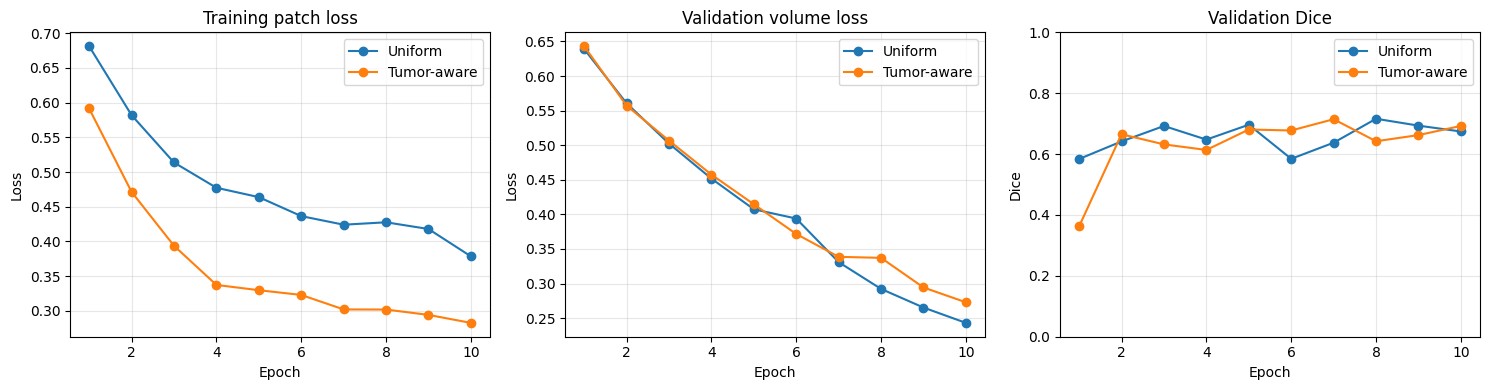


Uniform
Best epoch: 8; validation Dice: 0.716
Training loss: 0.681 → 0.379; validation loss: 0.639 → 0.243
Largest adjacent-epoch Dice change: 0.112
Possible overfitting: training loss decreased while validation Dice fell from its peak.
Check for instability: repeated oscillations are more concerning than a single early improvement.

Tumor-aware
Best epoch: 7; validation Dice: 0.715
Training loss: 0.592 → 0.283; validation loss: 0.643 → 0.273
Largest adjacent-epoch Dice change: 0.303
Training and validation improved. The short budget may still leave the model undertrained.
Check for instability: repeated oscillations are more concerning than a single early improvement.

Training loss uses augmented patches; validation loss uses complete volumes. Compare trends rather than absolute loss levels.


In [40]:
# Plot model learning curves and result-dependent observations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for name, history in [("Uniform", uniform_history), ("Tumor-aware", tumor_history),]:
    for ax, column in zip( axes, ["train_loss", "val_loss", "val_dice"]):
        ax.plot( history["epoch"], history[column],marker="o", label=name,)

for ax, title in zip( axes, ["Training patch loss", "Validation volume loss", "Validation Dice"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Loss")
axes[1].set_ylabel("Loss")
axes[2].set_ylabel("Dice")
axes[2].set_ylim(0, 1)

plt.tight_layout()
save_figure("D_learning_curves")

for name, history in [("Uniform", uniform_history), ("Tumor-aware", tumor_history),]:
    first, last = history.iloc[0], history.iloc[-1]
    best = history.loc[history["val_dice"].idxmax()]
    largest_change = history["val_dice"].diff().abs().max()

    print(f"\n{name}")
    print( f"Best epoch: {int(best.epoch)}; "
        f"validation Dice: {best.val_dice:.3f}" )
    print(f"Training loss: {first.train_loss:.3f} → {last.train_loss:.3f}; "
        f"validation loss: {first.val_loss:.3f} → {last.val_loss:.3f}")
    print(f"Largest adjacent-epoch Dice change: {largest_change:.3f}")

    # Using descriptive heuristics to confirm against the actual curves.
    if ( last.train_loss < first.train_loss and last.val_dice < best.val_dice - 0.03 ):
        print( "Possible overfitting: training loss decreased while validation Dice fell from its peak." )
    elif ( last.train_loss < first.train_loss and last.val_dice > first.val_dice + 0.02):
        print("Training and validation improved. The short budget may still leave the model undertrained.")
    else:
        print("Limited or mixed improvement: inspect for underfitting, a plateau, or instability.")

    if largest_change > 0.10:
        print("Check for instability: repeated oscillations are more concerning than a single early improvement.")

print("\nTraining loss uses augmented patches; validation loss uses complete volumes. Compare trends rather than absolute loss levels.")

#Part E
In this part I compare sampling and freeze the final configuration. 
I compare each sampler's best validation checkpoint using raw predictions. Mean case-wise validation
Dice selects the sampler; an exact tie selects uniform sampling. I then evaluate one predefined
postprocessing candidate: remove 6-connected predicted components smaller than **0.10 mL**. This
targets tiny isolated false positives while retaining multiple substantial lesions. It can erase genuine
small lesions, so it is not automatically appropriate. I keep it only if validation mean Dice strictly
improves and mean sensitivity falls by no more than 0.01. The threshold is not searched on test data.

In [41]:
# Here I evaluate both saved checkpoints on the same validation cases
def evaluate_sampling(model):
    records = []
    for row in val_rows.itertuples():
        folder = CACHE_DIR / row.case_id
        image = np.load(folder / "image.npy", mmap_mode="r")
        mask = np.load(folder / "mask.npy", mmap_mode="r")
        metadata = json.loads((folder / "geometry.json").read_text())
        region = tuple(slice(0, n) for n in metadata["original_shape_DHW"])
        reference = mask[0][region] > 0
        probability = sliding_window_probability(model, image, OVERLAP)[region]
        prediction = probability >= THRESHOLD

        tp = int(np.count_nonzero(prediction & reference))
        fp = int(np.count_nonzero(prediction & ~reference))
        fn = int(np.count_nonzero(~prediction & reference))

        denominator = 2 * tp + fp + fn
        dice = 2 * tp / denominator if denominator else 1.0
        sensitivity = tp / (tp + fn) if tp + fn else np.nan
        voxel_volume_ml = float(np.prod(metadata["spacing_DHW"]) / 1000)

        records.append({
            "case_id": row.case_id,
            "dice": dice,
            "sensitivity": sensitivity,
            "fp_ml": fp * voxel_volume_ml,
        })
    return pd.DataFrame(records)

print(f"Architecture: SmallUNet3D, base width {BASE_CHANNELS}, patch size {PATCH_SIZE}")
print(f"Shared loss: BCE + soft Dice; optimizer: Adam; learning rate: {LEARNING_RATE}; seed: {SEED}")

validation_results = []
for sampler in ["uniform", "tumor_aware"]:
    checkpoint = RUN_DIR / f"{sampler}_best.pt"
    assert checkpoint.is_file(), f"Missing checkpoint: {checkpoint}. Complete Part D first."
    model = SmallUNet3D(BASE_CHANNELS).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint, map_location=DEVICE, weights_only=True))
    model.eval()

    scores = evaluate_sampling(model)
    scores["sampler"] = sampler
    validation_results.append(scores)

    print(f"Validation evaluation complete: {sampler}", flush=True)
    del model

validation_results = pd.concat(validation_results, ignore_index=True)
save_table(validation_results, "E_validation_casewise")
validation_comparison = validation_results.groupby("sampler", sort=False)[["dice", "sensitivity", "fp_ml"]].mean().reset_index()

budget_columns = ["sampler", "optimizer_updates", "sampled_patches", "tumor_patch_fraction", "best_epoch"]
validation_comparison = validation_comparison.merge(comparison[budget_columns], on="sampler", sort=False)
save_table(validation_comparison, "E_sampling_comparison")

Architecture: SmallUNet3D, base width 8, patch size (64, 64, 64)
Shared loss: BCE + soft Dice; optimizer: Adam; learning rate: 0.001; seed: 42
Validation evaluation complete: uniform
Validation evaluation complete: tumor_aware


,case_id,dice,sensitivity,fp_ml,sampler
0,BRATS_006,0.924156,0.886547,6.969,uniform
1,BRATS_019,0.526652,0.583673,94.515,uniform
2,BRATS_020,0.896546,0.872149,18.861,uniform
3,BRATS_023,0.543285,0.955933,100.209,uniform
4,BRATS_028,0.597604,0.736813,58.052,uniform
...,...,...,...,...,...
141,BRATS_450,0.889663,0.991751,15.851,tumor_aware
142,BRATS_456,0.913563,0.904233,16.801,tumor_aware
143,BRATS_459,0.248465,0.899629,69.188,tumor_aware
144,BRATS_464,0.900456,0.907296,9.879,tumor_aware


,sampler,dice,sensitivity,fp_ml,optimizer_updates,sampled_patches,tumor_patch_fraction,best_epoch
0,uniform,0.716061,0.861590,38.548384,1000,2000,0.447,8
1,tumor_aware,0.714579,0.880203,43.851274,1000,2000,0.722,7


In [42]:
# Selecting one final configuration using validation evidence only.
scores_by_sampler = validation_comparison.set_index("sampler")

uniform_dice = scores_by_sampler.loc["uniform", "dice"]
tumor_dice = scores_by_sampler.loc["tumor_aware", "dice"]
selected_sampler = "tumor_aware" if tumor_dice > uniform_dice else "uniform"
selected_checkpoint = RUN_DIR / f"{selected_sampler}_best.pt"
selected_epoch = int(scores_by_sampler.loc[selected_sampler, "best_epoch"])

final_model = SmallUNet3D(BASE_CHANNELS).to(DEVICE)
final_model.load_state_dict(torch.load(selected_checkpoint, map_location=DEVICE, weights_only=True))
final_model.eval()

selected_config = {
    "sampler": selected_sampler,
    "checkpoint": selected_checkpoint.name,
    "best_epoch": selected_epoch,
    "validation_dice": float(scores_by_sampler.loc[selected_sampler, "dice"]),
    "architecture": "SmallUNet3D",
    "base_channels": BASE_CHANNELS,
    "patch_size": PATCH_SIZE,
    "overlap": OVERLAP,
    "threshold": THRESHOLD,
    "seed": SEED,
    "split_sha256": split_hash,
}

(RUN_DIR / "selected_config.json").write_text(json.dumps(selected_config, indent=2))

print("Selected sampler:", selected_sampler)
print("Selected checkpoint epoch:", selected_epoch)
print(f"Mean validation Dice: {selected_config['validation_dice']:.4f}")
print("The sampler was selected using validation evidence only. Test labels remain unused.")

Selected sampler: uniform
Selected checkpoint epoch: 8
Mean validation Dice: 0.7161
The sampler was selected using validation evidence only. Test labels remain unused.


Uniform sampling selects patches without considering tumor location, so some patches contain mostly background. Tumor-aware sampling deliberately includes more tumor-centred patches, giving the model more opportunities to learn tumor features. This can improve sensitivity and Dice, although improvement is not guaranteed. It also changes the surrounding context seen during training, which can affect predictions.
From the results we can see the one disadvantage of excessive tumor oversampling is that the model sees fewer examples of normal tissue and become sensitive to real world images. It may then predict tumor too readily, increasing false positives, therefore, I considered sensitivity and false-positive volume alongside Dice when comparing the methods.

# Part F
Here I reconstructed each volume using 64 × 64 × 64 patches with a stride of 32 voxels, giving 50% overlap along each axis. For voxels covered by multiple patches, I averaged the predicted probabilities with equal weights. I applied the 0.5 threshold only after averaging.


In [43]:
assert tuple(selected_config["patch_size"]) == tuple(PATCH_SIZE)
assert selected_config["overlap"] == OVERLAP
assert selected_config["threshold"] == THRESHOLD

stride = tuple(max(1, int(round(p * (1 - OVERLAP)))) for p in PATCH_SIZE)

print("Patch size:", PATCH_SIZE)
print("Stride:", stride)
print("Overlap:", f"{OVERLAP:.0%}")
print("Blending: equal-weight averaging of overlapping probabilities")
print("Threshold:", THRESHOLD)

Patch size: (64, 64, 64)
Stride: (32, 32, 32)
Overlap: 50%
Blending: equal-weight averaging of overlapping probabilities
Threshold: 0.5


In [44]:
def remove_small_components(mask, spacing, minimum_ml):
    structure = ndimage.generate_binary_structure(3, 1)
    components, _ = ndimage.label(mask, structure=structure)

    sizes = np.bincount(components.ravel())
    keep = sizes * np.prod(spacing) / 1000 >= minimum_ml
    keep[0] = False

    return keep[components]


def segmentation_metrics(prediction, reference, spacing):
    prediction = np.asarray(prediction, dtype=bool)
    reference = np.asarray(reference, dtype=bool)
    assert prediction.shape == reference.shape

    tp = int(np.count_nonzero(prediction & reference))
    fp = int(np.count_nonzero(prediction & ~reference))
    fn = int(np.count_nonzero(~prediction & reference))

    predicted_voxels = int(prediction.sum())
    reference_voxels = int(reference.sum())
    voxel_ml = float(np.prod(spacing) / 1000)

    dice = 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 1.0
    iou = tp / (tp + fp + fn) if tp + fp + fn else 1.0
    sensitivity = tp / reference_voxels if reference_voxels else np.nan

    if predicted_voxels == 0 and reference_voxels == 0:
        hd95 = 0.0
    elif predicted_voxels == 0 or reference_voxels == 0:
        hd95 = np.inf
    else:
        structure = ndimage.generate_binary_structure(3, 1)

        prediction_surface = prediction & ~ndimage.binary_erosion(prediction, structure=structure, border_value=0)
        reference_surface = reference & ~ndimage.binary_erosion(reference, structure=structure, border_value=0)

        to_reference = ndimage.distance_transform_edt(~reference_surface, sampling=spacing)[prediction_surface]
        to_prediction = ndimage.distance_transform_edt(~prediction_surface, sampling=spacing)[reference_surface]

        hd95 = float(max(np.percentile(to_reference, 95), np.percentile(to_prediction, 95)))

    absolute_error = abs(predicted_voxels - reference_voxels) * voxel_ml
    percentage_error = 100 * abs(predicted_voxels - reference_voxels) / reference_voxels if reference_voxels else np.nan

    return {
        "dice": dice,
        "iou": iou,
        "sensitivity": sensitivity,
        "hd95_mm": hd95,
        "fp_ml": fp * voxel_ml,
        "reference_ml": reference_voxels * voxel_ml,
        "prediction_ml": predicted_voxels * voxel_ml,
        "absolute_volume_error_ml": absolute_error,
        "percentage_volume_error": percentage_error,
        "empty_prediction": int(predicted_voxels == 0),
    }

Absolute volume error is the absolute difference between predicted and reference volumes. Percentage error is the absolute error divided by reference volume, multiplied by 100.
If exactly one mask is empty, HD95 is infinite.
And in the cell above, I calculated Dice, IoU, sensitivity, and HD95 for each complete volume. I also calculated tumor volume as the number of foreground voxels multiplied by voxel volume in mm³, divided by 1,000.

My candidate postprocessing rule removes 6-connected predicted components smaller than 0.10 mL. This targets small isolated false positives while allowing multiple larger tumor regions to remain. However, it can also remove genuine small lesions. Therefore, I assessed this one predefined rule on validation data. I retained it only if mean validation Dice improved and mean sensitivity decreased by no more than one percentage point.

In [45]:
def predict_cached_case(model, row):
    folder = CACHE_DIR / row.case_id

    image = np.load(folder / "image.npy", mmap_mode="r")
    mask = np.load(folder / "mask.npy", mmap_mode="r")
    metadata = json.loads((folder / "geometry.json").read_text())

    region = tuple(slice(0, n) for n in metadata["original_shape_DHW"])
    probability = sliding_window_probability(model, image, OVERLAP)[region]
    reference = np.asarray(mask[0][region], dtype=bool)
    return probability, reference, metadata


postprocessing_records = []
for row in val_rows.itertuples():
    probability, reference, metadata = predict_cached_case(final_model, row)
    spacing = metadata["spacing_DHW"]

    raw_prediction = probability >= THRESHOLD
    cleaned_prediction = remove_small_components(raw_prediction, spacing, MIN_COMPONENT_ML)

    for version, prediction in [("raw", raw_prediction), ("postprocessed", cleaned_prediction)]:
        metrics = segmentation_metrics(prediction, reference, spacing)
        postprocessing_records.append({"case_id": row.case_id, "version": version, **metrics})

postprocessing_results = pd.DataFrame(postprocessing_records)
postprocessing_validation = postprocessing_results.groupby("version", sort=False)[["dice", "sensitivity", "fp_ml"]].mean()

save_table(postprocessing_validation.reset_index(), "F_postprocessing_validation")

raw_scores = postprocessing_validation.loc["raw"]
cleaned_scores = postprocessing_validation.loc["postprocessed"]

# fixed acceptance rule is when model improves Dice without losing more than one percentage point of mean sensitivity.
use_postprocessing = bool( cleaned_scores["dice"] > raw_scores["dice"] and cleaned_scores["sensitivity"] >= raw_scores["sensitivity"] - 0.01 )
frozen_config = selected_config.copy()
frozen_config.update({
    "use_postprocessing": use_postprocessing,
    "minimum_component_ml": MIN_COMPONENT_ML,
    "component_connectivity": 6,
})

(RUN_DIR / "frozen_config.json").write_text(json.dumps(frozen_config, indent=2))
print("Component threshold:", MIN_COMPONENT_ML, "mL")
print("Postprocessing retained using validation evidence:", use_postprocessing)
print("Configuration fixed before test evaluation.")

,version,dice,sensitivity,fp_ml
0,raw,0.716061,0.861590,38.548384
1,postprocessed,0.716948,0.861523,38.317986


Component threshold: 0.1 mL
Postprocessing retained using validation evidence: True
Configuration fixed before test evaluation.


Now we move to evaluation of untouched test splits. This is the first stage that loads and preprocesses test-label arrays.

In [46]:
assert (RUN_DIR / "frozen_config.json").is_file()
assert hashlib.sha256(split_path.read_bytes()).hexdigest() == split_hash
cache_cases(test_rows)

test_records = []

for row in test_rows.itertuples():
    probability, reference, metadata = predict_cached_case(final_model, row)
    spacing = metadata["spacing_DHW"]

    raw_prediction = probability >= THRESHOLD
    cleaned_prediction = remove_small_components(raw_prediction, spacing, MIN_COMPONENT_ML)
    np.save(PROB_DIR / f"{row.case_id}.npy", probability)

    for version, prediction in [("raw", raw_prediction), ("postprocessed", cleaned_prediction)]:
        metrics = segmentation_metrics(prediction, reference, spacing)
        test_records.append({"case_id": row.case_id, "version": version, **metrics})
    print("Evaluated:", row.case_id, flush=True)

test_results = pd.DataFrame(test_records)

test_raw = test_results[test_results["version"] == "raw"].drop(columns="version").reset_index(drop=True)
test_post = test_results[test_results["version"] == "postprocessed"].drop(columns="version").reset_index(drop=True)

test_final = test_post.copy() if use_postprocessing else test_raw.copy()
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    save_table(test_raw, "F_test_raw_casewise")
    save_table(test_post, "F_test_postprocessed_casewise")

test_final.to_csv(TABLE_DIR / "F_test_final_casewise.csv", index=False)
print("Final reported method:", "postprocessed" if use_postprocessing else "raw")

Cached 1/73: BRATS_002
Cached 2/73: BRATS_012
Cached 3/73: BRATS_016
Cached 4/73: BRATS_033
Cached 5/73: BRATS_039
Cached 6/73: BRATS_050
Cached 7/73: BRATS_059
Cached 8/73: BRATS_065
Cached 9/73: BRATS_067
Cached 10/73: BRATS_078
Cached 11/73: BRATS_079
Cached 12/73: BRATS_088
Cached 13/73: BRATS_097
Cached 14/73: BRATS_108
Cached 15/73: BRATS_112
Cached 16/73: BRATS_131
Cached 17/73: BRATS_137
Cached 18/73: BRATS_141
Cached 19/73: BRATS_142
Cached 20/73: BRATS_144
Cached 21/73: BRATS_156
Cached 22/73: BRATS_158
Cached 23/73: BRATS_163
Cached 24/73: BRATS_168
Cached 25/73: BRATS_169
Cached 26/73: BRATS_171
Cached 27/73: BRATS_173
Cached 28/73: BRATS_188
Cached 29/73: BRATS_192
Cached 30/73: BRATS_198
Cached 31/73: BRATS_222
Cached 32/73: BRATS_230
Cached 33/73: BRATS_241
Cached 34/73: BRATS_246
Cached 35/73: BRATS_247
Cached 36/73: BRATS_249
Cached 37/73: BRATS_250
Cached 38/73: BRATS_252
Cached 39/73: BRATS_253
Cached 40/73: BRATS_260
Cached 41/73: BRATS_262
Cached 42/73: BRATS_281
C

,case_id,dice,iou,sensitivity,hd95_mm,fp_ml,reference_ml,prediction_ml,absolute_volume_error_ml,percentage_volume_error,empty_prediction
0,BRATS_002,0.786488,0.648109,0.978767,93.555598,32.173,63.061,93.895,30.834,48.895514,0
1,BRATS_012,0.379983,0.234555,0.844662,107.506279,56.213,21.611,74.467,52.856,244.579150,0
2,BRATS_016,0.866348,0.764209,0.930459,25.362303,17.997,82.728,94.972,12.244,14.800309,0
3,BRATS_033,0.909625,0.834231,0.909968,84.675853,10.351,114.015,114.101,0.086,0.075429,0
4,BRATS_039,0.830948,0.710788,0.846247,43.588416,7.054,37.014,38.377,1.363,3.682390,0
5,BRATS_050,0.916506,0.845881,0.896508,3.741657,4.563,76.238,72.911,3.327,4.363965,0
6,BRATS_059,0.933558,0.875396,0.938917,2.449490,7.225,99.569,100.712,1.143,1.147948,0
7,BRATS_065,0.804927,0.673538,0.899669,12.247449,55.763,166.091,205.190,39.099,23.540710,0
8,BRATS_067,0.905213,0.826840,0.960237,40.753527,8.918,55.277,61.997,6.720,12.156955,0
9,BRATS_078,0.573871,0.402397,0.871196,34.799425,99.123,85.083,173.247,88.164,103.621170,0


,case_id,dice,iou,sensitivity,hd95_mm,fp_ml,reference_ml,prediction_ml,absolute_volume_error_ml,percentage_volume_error,empty_prediction
0,BRATS_002,0.788492,0.650836,0.978767,93.193347,31.774,63.061,93.496,30.435,48.262793,0
1,BRATS_012,0.381488,0.235703,0.844662,107.563934,55.834,21.611,74.088,52.477,242.825413,0
2,BRATS_016,0.867539,0.766065,0.930459,21.362347,17.753,82.728,94.728,12.000,14.505367,0
3,BRATS_033,0.910251,0.835286,0.909968,84.537565,10.194,114.015,113.944,0.071,0.062273,0
4,BRATS_039,0.832394,0.712907,0.846247,42.394575,6.923,37.014,38.246,1.232,3.328470,0
5,BRATS_050,0.916808,0.846394,0.896508,3.741657,4.514,76.238,72.862,3.376,4.428238,0
6,BRATS_059,0.934263,0.876635,0.938917,2.449490,7.074,99.569,100.561,0.992,0.996294,0
7,BRATS_065,0.805150,0.673850,0.899669,12.083046,55.660,166.091,205.087,38.996,23.478695,0
8,BRATS_067,0.907364,0.830436,0.960237,39.580295,8.640,55.277,61.719,6.442,11.654033,0
9,BRATS_078,0.574200,0.402721,0.871173,34.770677,98.970,85.083,173.092,88.009,103.438995,0


Final reported method: postprocessed


In [47]:
def summarize_metrics(table):
    columns = ["dice", "iou", "sensitivity", "hd95_mm", "fp_ml", "reference_ml", "prediction_ml", "absolute_volume_error_ml", "percentage_volume_error"]
    rows = []

    for column in columns:
        values = table[column].dropna().to_numpy(dtype=float)
        rows.append({
            "metric": column,
            "mean": float(np.mean(values)) if len(values) else np.nan,
            "std": float(np.std(values, ddof=0)) if len(values) and np.isfinite(values).all() else np.nan,
            "median": float(np.median(values)) if len(values) else np.nan,
            "undefined_cases": int(table[column].isna().sum()),
            "infinite_cases": int(np.isinf(values).sum()),
        })
    return pd.DataFrame(rows)


save_table(summarize_metrics(test_raw), "F_test_raw_summary")
save_table(summarize_metrics(test_post), "F_test_postprocessed_summary")
empty_counts = pd.DataFrame({
    "version": ["raw", "postprocessed"],
    "test_cases": [len(test_raw), len(test_post)],
    "empty_predictions": [int(test_raw["empty_prediction"].sum()), int(test_post["empty_prediction"].sum())],
})

save_table(empty_counts, "F_empty_predictions")
print("Empty predictions for the final method:", int(test_final["empty_prediction"].sum()))

,metric,mean,std,median,undefined_cases,infinite_cases
0,dice,0.788684,0.146688,0.822937,0,0
1,iou,0.672081,0.176353,0.699145,0,0
2,sensitivity,0.867417,0.103916,0.902116,0,0
3,hd95_mm,39.198633,28.922012,41.704316,0,0
4,fp_ml,22.833918,22.803880,17.054000,0,0
5,reference_ml,107.388123,65.822507,89.113000,0,0
6,prediction_ml,113.891945,50.388087,103.895000,0,0
7,absolute_volume_error_ml,23.298945,23.793520,15.565000,0,0
8,percentage_volume_error,51.795754,158.428917,14.800309,0,0


,metric,mean,std,median,undefined_cases,infinite_cases
0,dice,0.789834,0.146246,0.823222,0,0
1,iou,0.673557,0.175944,0.699556,0,0
2,sensitivity,0.867350,0.103948,0.902116,0,0
3,hd95_mm,38.700957,28.992398,41.665333,0,0
4,fp_ml,22.605288,22.760027,16.469000,0,0
5,reference_ml,107.388123,65.822507,89.113000,0,0
6,prediction_ml,113.655493,50.471805,103.729000,0,0
7,absolute_volume_error_ml,23.182548,23.769660,15.577000,0,0
8,percentage_volume_error,51.409803,158.028363,14.505367,0,0


,version,test_cases,empty_predictions
0,raw,73,0
1,postprocessed,73,0


Empty predictions for the final method: 0


I summarized the case-wise results using the mean, population standard deviation, and median. Undefined values are excluded from these calculations and their counts are reported. Infinite HD95 values are retained: they make the mean infinite and the standard deviation undefined, rather than hiding empty-mask failures.

Completion of Part B:
I am calculating test splits and reference volumes only after model and preprocessing. 

In [48]:
test_volumes = reference_volume_table(test_rows)
all_volumes = pd.concat([development_volumes, test_volumes], ignore_index=True)

all_volume_summary = all_volumes.groupby("split")["tumor_volume_ml"].agg(["count", "mean", "std", "median", "min", "max"]).reset_index()

save_table(all_volumes, "B_all_reference_volumes")
save_table(all_volume_summary, "B_all_volume_distributions")

,case_id,split,tumor_volume_ml
0,BRATS_001,train,111.724
1,BRATS_003,train,173.927
2,BRATS_004,train,120.660
3,BRATS_005,train,80.680
4,BRATS_007,train,61.085
...,...,...,...
479,BRATS_462,test,38.314
480,BRATS_466,test,16.748
481,BRATS_467,test,157.749
482,BRATS_481,test,57.168


,split,count,mean,std,median,min,max
0,test,73,107.388123,66.278032,89.1130,10.101,318.345
1,train,338,102.964050,56.960258,95.4845,8.478,265.254
2,validation,73,100.764836,62.950123,91.5600,7.285,266.936


# Part G
In this part, I will be doing error and limitations analysis. 

Cases are ranked using final whole-volume Dice. 

In [49]:
ranked_cases = test_final.sort_values(['dice', 'case_id']).reset_index(drop=True)
assert len(ranked_cases) >= 3, 'At least three test cases are needed.'

positions = [len(ranked_cases) - 1, (len(ranked_cases) - 1) // 2, 0]
selected_cases = ranked_cases.iloc[positions].copy()
selected_cases.insert(0, 'rank', ['Best', 'Median', 'Worst'])

columns = ['rank', 'case_id', 'dice', 'hd95_mm', 'reference_ml', 'prediction_ml', 'absolute_volume_error_ml', 'percentage_volume_error']
save_table(selected_cases[columns], 'G_selected_cases_metrics')

,rank,case_id,dice,hd95_mm,reference_ml,prediction_ml,absolute_volume_error_ml,percentage_volume_error
72,Best,BRATS_112,0.963280,2.000000,169.185,163.736,5.449,3.220735
36,Median,BRATS_156,0.823222,9.000000,222.612,171.204,51.408,23.093095
0,Worst,BRATS_376,0.118035,43.931765,10.101,144.921,134.820,1334.719335


Here we display three-plane overlays and quantify the boundary errors. 

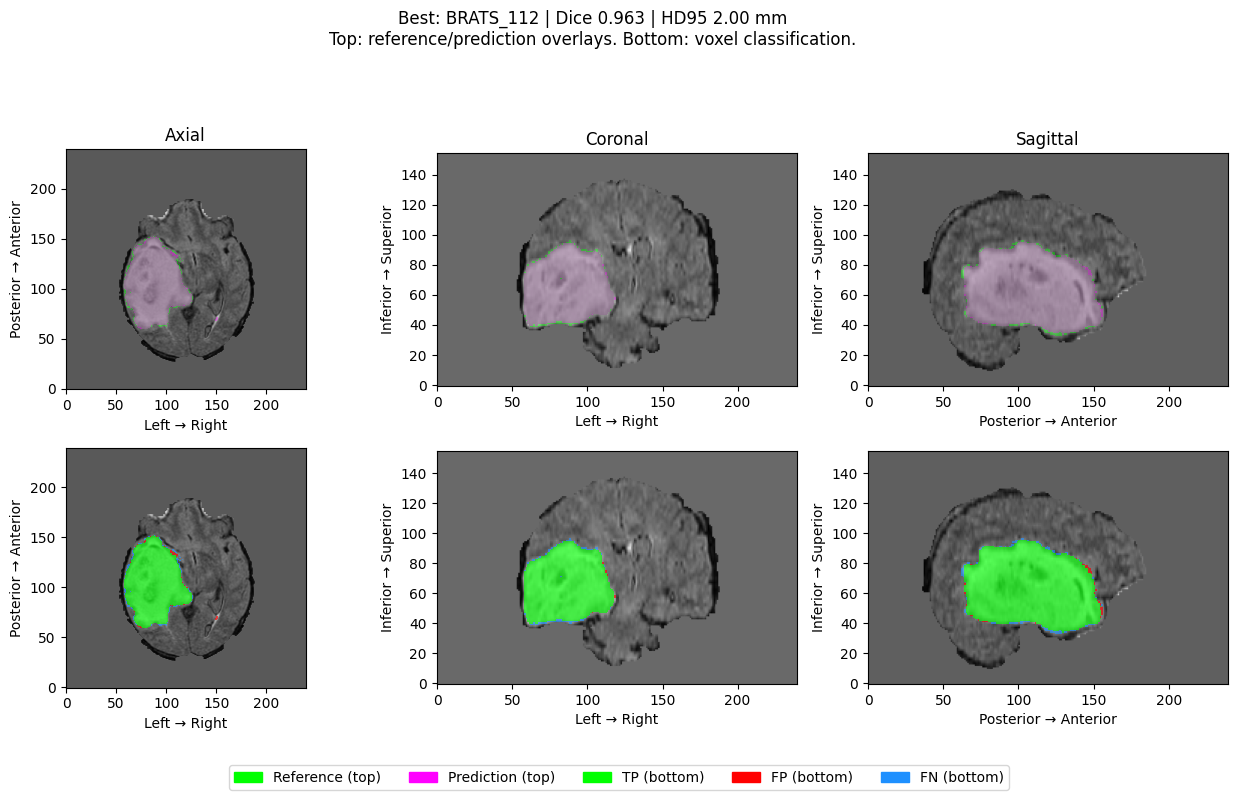

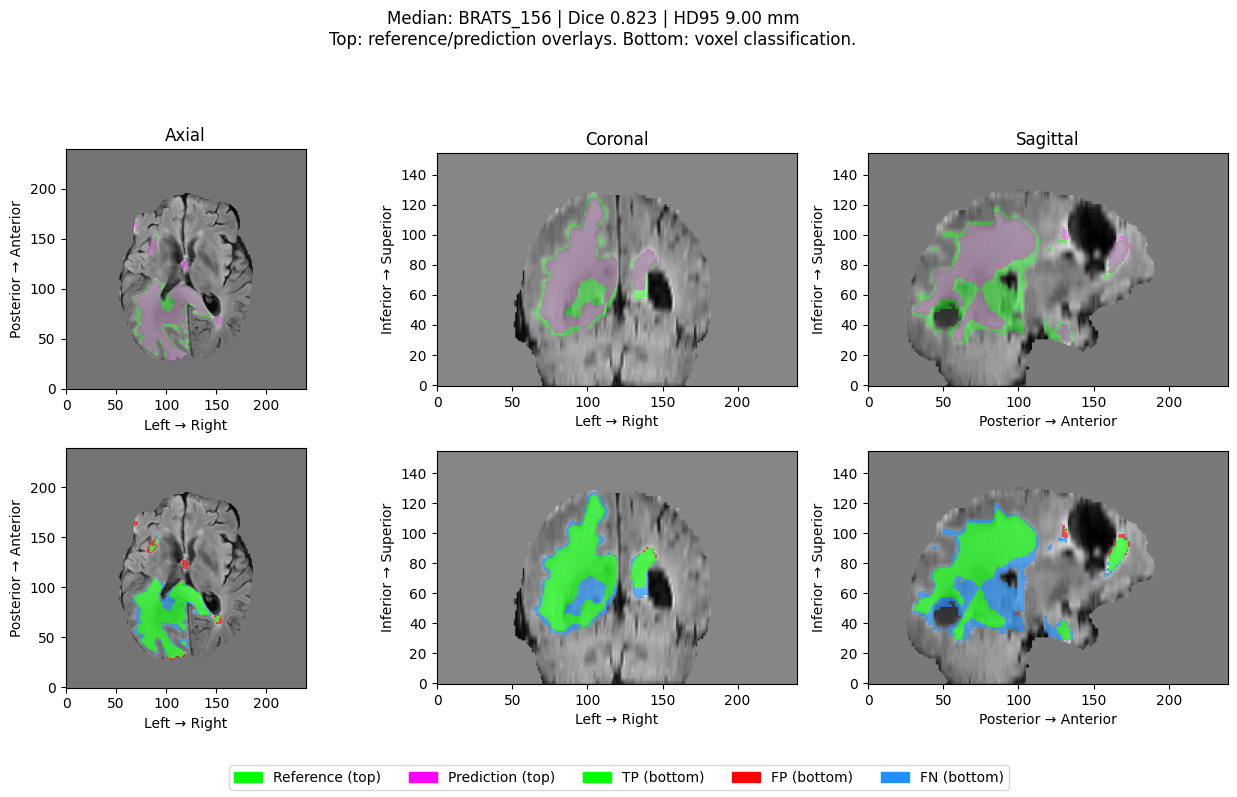

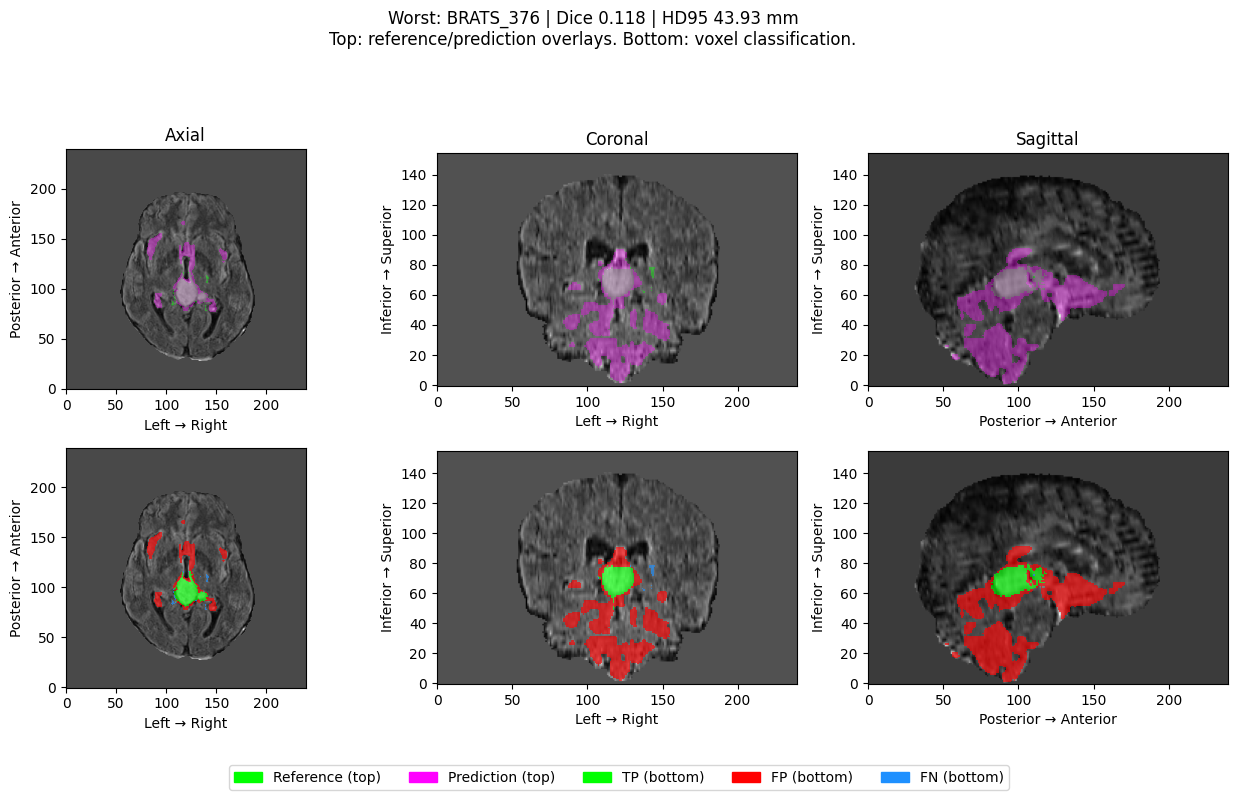

,rank,case_id,fp_voxels,fn_voxels,errors_within_2mm_percent
0,Best,BRATS_112,3388,8837,92.286299
1,Median,BRATS_156,9105,60513,78.986756
2,Worst,BRATS_376,135772,952,4.011000


In [50]:
def plane_slices(array, point):
    d, h, w = point
    return [array[d, :, :], array[:, h, :], array[:, :, w]]
def show_case_errors(row):
    folder = CACHE_DIR / row.case_id
    metadata = json.loads((folder / 'geometry.json').read_text())
    region = tuple(slice(0, n) for n in metadata['original_shape_DHW'])
    spacing = np.array(metadata['spacing_DHW'])

    image = np.load(folder / 'image.npy', mmap_mode='r')[(slice(None),) + region]
    reference = np.load(folder / 'mask.npy', mmap_mode='r')[0][region] > 0
    probability = np.load(PROB_DIR / f'{row.case_id}.npy')
    assert probability.shape == reference.shape

    prediction = probability >= frozen_config['threshold']
    if frozen_config['use_postprocessing']:
        prediction = remove_small_components(prediction, spacing, frozen_config['minimum_component_ml'])

    tp = prediction & reference
    fp = prediction & ~reference
    fn = ~prediction & reference

    denominator = int(prediction.sum()) + int(reference.sum())
    reconstructed_dice = 2 * int(tp.sum()) / denominator if denominator else 1.0
    assert np.isclose(reconstructed_dice, row.dice), 'Prediction does not match the Part F results.'

    focus = reference if reference.any() else prediction
    coordinates = np.argwhere(focus)

    if len(coordinates):
        centre = coordinates.mean(axis=0)
        point = coordinates[np.argmin(np.sum((coordinates - centre) ** 2, axis=1))]
    else:
        point = np.array(reference.shape) // 2

    errors = np.zeros(reference.shape, dtype=np.uint8)
    errors[tp] = 1
    errors[fp] = 2
    errors[fn] = 3

    flair_views = plane_slices(image[CHANNELS.index('FLAIR')], point)
    reference_views = plane_slices(reference, point)
    prediction_views = plane_slices(prediction, point)
    error_views = plane_slices(errors, point)

    sz, sy, sx = spacing
    aspects = [sy / sx, sz / sx, sz / sy]
    axis_labels = [('Left → Right', 'Posterior → Anterior'), ('Left → Right', 'Inferior → Superior'), ('Posterior → Anterior', 'Inferior → Superior')]

    fig, axes = plt.subplots(2, 3, figsize=(13, 8))

    for i, plane in enumerate(['Axial', 'Coronal', 'Sagittal']):
        for ax in axes[:, i]:
            ax.imshow(flair_views[i], cmap='gray', origin='lower', aspect=aspects[i])
            ax.set_xlabel(axis_labels[i][0])
            ax.set_ylabel(axis_labels[i][1])

        ref_overlay = np.ma.masked_where(~reference_views[i], reference_views[i])
        pred_overlay = np.ma.masked_where(~prediction_views[i], prediction_views[i])
        error_overlay = np.ma.masked_where(error_views[i] == 0, error_views[i])

        axes[0, i].imshow(ref_overlay, cmap=ListedColormap(['lime']), vmin=0, vmax=1, alpha=0.4, origin='lower', aspect=aspects[i], interpolation='nearest')
        axes[0, i].imshow(pred_overlay, cmap=ListedColormap(['magenta']), vmin=0, vmax=1, alpha=0.35, origin='lower', aspect=aspects[i], interpolation='nearest')
        axes[1, i].imshow(error_overlay, cmap=ListedColormap(['lime', 'red', 'dodgerblue']), vmin=1, vmax=3, alpha=0.65, origin='lower', aspect=aspects[i], interpolation='nearest')
        axes[0, i].set_title(plane)

    legend_items = [('lime', 'Reference (top)'), ('magenta', 'Prediction (top)'), ('lime', 'TP (bottom)'), ('red', 'FP (bottom)'), ('dodgerblue', 'FN (bottom)')]
    handles = [Patch(color=color, label=label) for color, label in legend_items]
    fig.legend(handles=handles, loc='lower center', ncol=5)

    fig.suptitle(f'{row.rank}: {row.case_id} | Dice {row.dice:.3f} | HD95 {row.hd95_mm:.2f} mm\nTop: reference/prediction overlays. Bottom: voxel classification.')
    plt.tight_layout(rect=(0, 0.06, 1, 0.92))
    save_figure(f'G_{row.rank.lower()}_{row.case_id}')

    error_voxels = fp | fn
    boundary_percentage = np.nan

    if reference.any() and error_voxels.any():
        structure = ndimage.generate_binary_structure(3, 1)
        surface = reference & ~ndimage.binary_erosion(reference, structure=structure, border_value=0)
        distance = ndimage.distance_transform_edt(~surface, sampling=spacing)
        boundary_percentage = 100 * np.mean(distance[error_voxels] <= 2.0)

    return {'rank': row.rank, 'case_id': row.case_id, 'fp_voxels': int(fp.sum()), 'fn_voxels': int(fn.sum()), 'errors_within_2mm_percent': boundary_percentage}

error_details = pd.DataFrame([show_case_errors(row) for row in selected_cases.itertuples(index=False)])
save_table(error_details, 'G_error_details')

I selected the best, median and worst test cases according to whole-tumor Dice for the final configuration chosen using validation results. For each case, I displayed axial, coronal and sagittal slices through the same location near the reference tumor centre. 
The reference and prediction overlays show their spatial agreement. The error maps distinguish correctly predicted tumor voxels in green, extra predicted voxels in red, and missed tumor voxels in blue.

FOr this error analysis we need several metrics because each metric show different issues. For example, dice measures overall overlap, while HD95 measures boundary disagreement in millimetres, and volume error measures the difference in total tumor size. A prediction can have good Dice while part of its boundary is misplaced. HD95 can reveal this disagreement, although very small isolated errors may fall outside its 95th-percentile measurement.
A small volume error does not necessarily mean an accurate segmentation. Extra predicted voxels and missed tumor voxels can cancel in the total volume even when their locations are incorrect. I therefore interpreted these metrics together with the three-plane error maps.

Now regarding the limitations:
1. The small training budget and lightweight model may underfit; a 64³ patch limits anatomical context.
2. Only one split and one seed are used; the comparison does not measure variability across repeated runs.
3. There is no external-site validation, so scanner, hospital and protocol generalization are untested.
4. Whole-tumor binarization discards clinically distinct subregions; the reference is not pathology-confirmed extent.
5. The small-component rule can remove genuine satellite lesions. The displayed three slices do not show every error.
6. Resampling and the chosen HD95 convention affect quantitative results; consistent physical units remain essential.


#Bonus Task 1:
Missing Modality stress test.


In [51]:
def apply_final_rule(probability, meta):
    prediction = probability >= frozen_config['threshold']

    if frozen_config['use_postprocessing']:
        prediction = remove_small_components(prediction, meta['spacing_DHW'], frozen_config['minimum_component_ml'])
    return prediction

In [52]:
baseline_results = test_final.set_index('case_id')
missing_rows = []
final_model.eval()

for row in test_rows.itertuples(index=False):
    folder = CACHE_DIR / row.case_id
    image = np.load(folder / 'image.npy', mmap_mode='r')
    mask = np.load(folder / 'mask.npy', mmap_mode='r')
    meta = json.loads((folder / 'geometry.json').read_text())

    region = tuple(slice(0, n) for n in meta['original_shape_DHW'])
    reference = mask[0][region] > 0

    baseline = baseline_results.loc[row.case_id].to_dict()
    missing_rows.append({'case_id': row.case_id, 'condition': 'All four', **baseline})

    for index, name in enumerate(CHANNELS):
        ablated = np.array(image, copy=True)
        ablated[index] = 0

        probability = sliding_window_probability(final_model, ablated, frozen_config['overlap'])[region]
        prediction = apply_final_rule(probability, meta)
        metrics = segmentation_metrics(prediction, reference, meta['spacing_DHW'])

        missing_rows.append({'case_id': row.case_id, 'condition': f'Without {name}', **metrics})
        del ablated, probability, prediction

    print('Missing-modality experiment:', row.case_id, flush=True)

missing_results = pd.DataFrame(missing_rows)
save_table(missing_results, 'bonus1_missing_modalities_casewise')


Missing-modality experiment: BRATS_002
Missing-modality experiment: BRATS_012
Missing-modality experiment: BRATS_016
Missing-modality experiment: BRATS_033
Missing-modality experiment: BRATS_039
Missing-modality experiment: BRATS_050
Missing-modality experiment: BRATS_059
Missing-modality experiment: BRATS_065
Missing-modality experiment: BRATS_067
Missing-modality experiment: BRATS_078
Missing-modality experiment: BRATS_079
Missing-modality experiment: BRATS_088
Missing-modality experiment: BRATS_097
Missing-modality experiment: BRATS_108
Missing-modality experiment: BRATS_112
Missing-modality experiment: BRATS_131
Missing-modality experiment: BRATS_137
Missing-modality experiment: BRATS_141
Missing-modality experiment: BRATS_142
Missing-modality experiment: BRATS_144
Missing-modality experiment: BRATS_156
Missing-modality experiment: BRATS_158
Missing-modality experiment: BRATS_163
Missing-modality experiment: BRATS_168
Missing-modality experiment: BRATS_169
Missing-modality experime

,case_id,condition,dice,iou,sensitivity,hd95_mm,fp_ml,reference_ml,prediction_ml,absolute_volume_error_ml,percentage_volume_error,empty_prediction
0,BRATS_002,All four,0.788492,0.650836,0.978767,93.193347,31.774,63.061,93.496,30.435,48.262793,0.0
1,BRATS_002,Without FLAIR,0.021429,0.010831,0.010831,33.211440,0.000,63.061,0.683,62.378,98.916922,0.0
2,BRATS_002,Without T1,0.623922,0.453406,0.988598,93.152563,74.436,63.061,136.778,73.717,116.897924,0.0
3,BRATS_002,Without T1ce,0.816955,0.690553,0.971742,97.406879,25.678,63.061,86.957,23.896,37.893468,0.0
4,BRATS_002,Without T2,0.867307,0.765703,0.966160,63.245157,16.509,63.061,77.436,14.375,22.795389,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
360,BRATS_482,All four,0.687467,0.523771,0.679970,59.152346,55.087,184.720,180.691,4.029,2.181139,0.0
361,BRATS_482,Without FLAIR,0.021154,0.010690,0.010941,44.997222,4.337,184.720,6.358,178.362,96.558034,0.0
362,BRATS_482,Without T1,0.612041,0.440964,0.689443,59.140933,104.088,184.720,231.442,46.722,25.293417,0.0
363,BRATS_482,Without T1ce,0.703983,0.543189,0.728459,59.203040,63.004,184.720,197.565,12.845,6.953768,0.0


,condition,metric,mean,std,median,undefined_cases,infinite_cases
0,All four,dice,0.789834,0.146246,0.823222,0,0
1,All four,hd95_mm,38.700957,28.992398,41.665333,0,0
2,All four,absolute_volume_error_ml,23.182548,23.769660,15.577000,0,0
3,All four,percentage_volume_error,51.409803,158.028363,14.505367,0,0
4,Without FLAIR,dice,0.114711,0.115308,0.086060,0,0
5,Without FLAIR,hd95_mm,inf,NaN,42.720019,0,15
6,Without FLAIR,absolute_volume_error_ml,98.187014,60.667730,82.268000,0,0
7,Without FLAIR,percentage_volume_error,92.137018,8.019385,93.961156,0,0
8,Without T1,dice,0.733408,0.180509,0.754022,0,0
9,Without T1,hd95_mm,45.627771,26.493586,44.513481,0,0


metric,condition,dice,hd95_mm,absolute_volume_error_ml,percentage_volume_error
0,All four,0.789834,38.700957,23.182548,51.409803
1,Without FLAIR,0.114711,inf,98.187014,92.137018
2,Without T1,0.733408,45.627771,35.846466,82.314109
3,Without T1ce,0.774562,41.936245,24.821301,58.603648
4,Without T2,0.754706,36.839110,28.831082,44.327853


,condition,paired_mean_dice_change
0,Without FLAIR,-0.675122
1,Without T1,-0.056425
2,Without T1ce,-0.015271
3,Without T2,-0.035128


Most influential channel(s) by mean Dice decrease: FLAIR
Mean Dice decrease: 0.6751


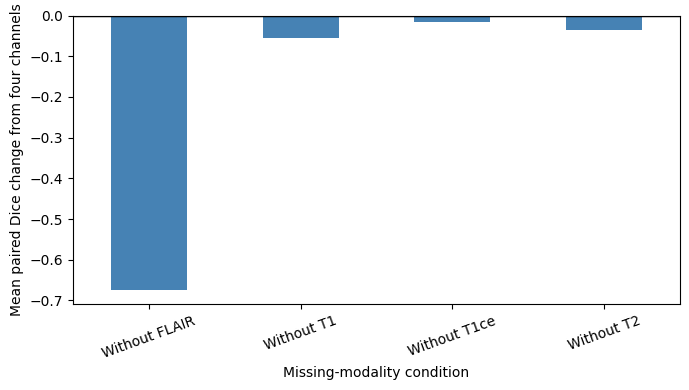

In [53]:
metric_columns = ['dice', 'hd95_mm', 'absolute_volume_error_ml', 'percentage_volume_error']
summary_tables = []

for name, group in missing_results.groupby('condition', sort=False):
    summary = summarize_metrics(group)
    summary = summary[summary['metric'].isin(metric_columns)].copy()
    summary.insert(0, 'condition', name)
    summary_tables.append(summary)

missing_summary = pd.concat(summary_tables, ignore_index=True)
save_table(missing_summary, 'bonus1_missing_modalities_summary')

mean_comparison = missing_summary.pivot(index='condition', columns='metric', values='mean')
condition_order = ['All four'] + [f'Without {name}' for name in CHANNELS]
mean_comparison = mean_comparison.reindex(condition_order)[metric_columns]
save_table(mean_comparison.reset_index(), 'bonus1_mean_comparison')
dice_by_condition = missing_results.pivot(index='case_id', columns='condition', values='dice')
mean_changes = dice_by_condition.subtract(dice_by_condition['All four'], axis=0).mean().drop('All four')

save_table(mean_changes.rename('paired_mean_dice_change').reset_index(), 'bonus1_paired_dice_changes')
largest_decrease = mean_changes.min()

if largest_decrease < 0:
    influential = mean_changes.index[np.isclose(mean_changes.values, largest_decrease)]
    influential_names = [name.replace('Without ', '') for name in influential]
    print('Most influential channel(s) by mean Dice decrease:', ', '.join(influential_names))
    print(f'Mean Dice decrease: {-largest_decrease:.4f}')
else:
    print('No channel removal reduced mean Dice in this experiment.')

ax = mean_changes.plot.bar(figsize=(7, 4), color='steelblue')
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('Mean paired Dice change from four channels')
ax.set_xlabel('Missing-modality condition')
plt.xticks(rotation=20)
plt.tight_layout()
save_figure('bonus1_missing_modality_dice')

In this bonus qestion, I evaluated the effect of missing MRI modalities by replacing each normalized channel with zeros separately, without retraining the model. I kept the other channels, inference settings, threshold and postprocessing unchanged. This allowed a controlled comparison against the four-channel baseline.
Removing FLAIR caused the largest decrease in mean Dice, from 0.7898 to 0.1147, a decrease of 0.6751, making it the most influential channel for this trained model on this test split. Mean HD95 changed from 38.70 mm to infinity, with 15 cases having infinite HD95, while mean absolute volume error changed from 23.18 mL to 98.19 mL. These metrics describe different effects: Dice measures overlap, HD95 measures boundary disagreement, and volume error measures disagreement in total tumor size. Their rankings do not necessarily match because extra and missed voxels can cancel when calculating volume.
Zeroing is an imperfect simulation of a missing acquisition. After normalization, zero represents the mean foreground intensity and is also used for background. An entirely zero channel is therefore an artificial input, without an explicit indication that the acquisition is unavailable. The experiment measures both information loss and sensitivity to an unfamiliar input pattern.
To redesign training, I would randomly drop
modalities during training and provide a channel-availability indicator, then validate on predefined missing-modality conditions. I would not tune that redesign using these test labels.

# Bonus qestion 2:
Compare inference at three overlap settings

In [54]:
overlap_values = [0.0, 0.25, 0.50]
seam_records = []
example_probabilities = {}
example_case = test_rows.iloc[0]['case_id']

assert tuple(PATCH_SIZE) == tuple(frozen_config['patch_size'])
final_model.eval()

with torch.no_grad():
    warmup = torch.zeros((1, len(CHANNELS), *PATCH_SIZE), device=DEVICE)
    final_model(warmup)
    del warmup

for row in test_rows.itertuples(index=False):
    folder = CACHE_DIR / row.case_id
    image = np.load(folder / 'image.npy', mmap_mode='r')
    mask = np.load(folder / 'mask.npy', mmap_mode='r')
    meta = json.loads((folder / 'geometry.json').read_text())

    region = tuple(slice(0, n) for n in meta['original_shape_DHW'])
    reference = mask[0][region] > 0

    for overlap in overlap_values:
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()

        started = time.perf_counter()
        probability = sliding_window_probability(final_model, image, overlap)

        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()

        seconds = time.perf_counter() - started
        probability = probability[region]

        prediction = apply_final_rule(probability, meta)
        metrics = segmentation_metrics(prediction, reference, meta['spacing_DHW'])
        seam_records.append({'case_id': row.case_id, 'overlap': overlap, 'seconds': seconds, **metrics})

        if row.case_id == example_case:
            middle_slice = probability.shape[0] // 2
            example_probabilities[overlap] = probability[middle_slice].copy()
            example_shape = image.shape[1:]
            example_spacing = meta['spacing_DHW']

        del probability, prediction

    print('Overlap experiment:', row.case_id, flush=True)

seam_results = pd.DataFrame(seam_records)
save_table(seam_results, 'bonus2_overlap_casewise')

Overlap experiment: BRATS_002
Overlap experiment: BRATS_012
Overlap experiment: BRATS_016
Overlap experiment: BRATS_033
Overlap experiment: BRATS_039
Overlap experiment: BRATS_050
Overlap experiment: BRATS_059
Overlap experiment: BRATS_065
Overlap experiment: BRATS_067
Overlap experiment: BRATS_078
Overlap experiment: BRATS_079
Overlap experiment: BRATS_088
Overlap experiment: BRATS_097
Overlap experiment: BRATS_108
Overlap experiment: BRATS_112
Overlap experiment: BRATS_131
Overlap experiment: BRATS_137
Overlap experiment: BRATS_141
Overlap experiment: BRATS_142
Overlap experiment: BRATS_144
Overlap experiment: BRATS_156
Overlap experiment: BRATS_158
Overlap experiment: BRATS_163
Overlap experiment: BRATS_168
Overlap experiment: BRATS_169
Overlap experiment: BRATS_171
Overlap experiment: BRATS_173
Overlap experiment: BRATS_188
Overlap experiment: BRATS_192
Overlap experiment: BRATS_198
Overlap experiment: BRATS_222
Overlap experiment: BRATS_230
Overlap experiment: BRATS_241
Overlap ex

,case_id,overlap,seconds,dice,iou,sensitivity,hd95_mm,fp_ml,reference_ml,prediction_ml,absolute_volume_error_ml,percentage_volume_error,empty_prediction
0,BRATS_002,0.00,5.605149,0.799005,0.665285,0.980083,93.537419,29.839,63.061,91.644,28.583,45.325954,0
1,BRATS_002,0.25,8.706489,0.783883,0.644578,0.980876,87.410240,32.901,63.061,94.756,31.695,50.260859,0
2,BRATS_002,0.50,21.824676,0.788492,0.650836,0.978767,93.193347,31.774,63.061,93.496,30.435,48.262793,0
3,BRATS_012,0.00,5.446202,0.358850,0.218658,0.842719,107.377838,61.679,21.611,79.891,58.280,269.677479,0
4,BRATS_012,0.25,8.020337,0.382281,0.236308,0.851742,107.348032,56.283,21.611,74.690,53.079,245.611031,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,BRATS_481,0.25,8.285658,0.824215,0.700991,0.881192,59.016947,14.696,57.168,65.072,7.904,13.825917,0
215,BRATS_481,0.50,21.661803,0.821131,0.696542,0.874528,58.565775,14.608,57.168,64.603,7.435,13.005528,0
216,BRATS_482,0.00,5.397788,0.699210,0.537527,0.694549,59.371710,53.960,184.720,182.257,2.463,1.333369,0
217,BRATS_482,0.25,8.068434,0.690737,0.527577,0.709598,59.169249,63.731,184.720,194.808,10.088,5.461239,0


In [55]:
#SUmmarizing runtime and metrics
seam_summaries = []
comparison_records = []
seam_metrics = ['dice', 'hd95_mm', 'absolute_volume_error_ml', 'percentage_volume_error']

for overlap, group in seam_results.groupby('overlap', sort=True):
    summary = summarize_metrics(group)
    summary = summary[summary['metric'].isin(seam_metrics)].copy()
    summary.insert(0, 'overlap', overlap)
    seam_summaries.append(summary)

    record = {
        'overlap_percent': int(overlap * 100),
        'stride': tuple(int(round(p * (1 - overlap))) for p in PATCH_SIZE),
        'mean_seconds_per_case': group['seconds'].mean(),
        'total_seconds': group['seconds'].sum(),
        'empty_predictions': int(group['empty_prediction'].sum()),
        'infinite_hd95_cases': int(np.isinf(group['hd95_mm']).sum()),
    }

    record.update(summary.set_index('metric')['mean'].to_dict())
    comparison_records.append(record)

seam_summary = pd.concat(seam_summaries, ignore_index=True)
seam_comparison = pd.DataFrame(comparison_records)

save_table(seam_summary, 'bonus2_overlap_metric_summary')
save_table(seam_comparison, 'bonus2_overlap_comparison')

,overlap,metric,mean,std,median,undefined_cases,infinite_cases
0,0.00,dice,0.783163,0.150598,0.822793,0,0
1,0.00,hd95_mm,39.268578,27.966856,42.276470,0,0
2,0.00,absolute_volume_error_ml,24.393247,26.654941,14.786000,0,0
3,0.00,percentage_volume_error,57.109356,187.415169,16.960932,0,0
4,0.25,dice,0.787635,0.149485,0.826308,0,0
5,0.25,hd95_mm,38.771481,28.967496,42.965102,0,0
6,0.25,absolute_volume_error_ml,23.704027,23.914086,14.895000,0,0
7,0.25,percentage_volume_error,53.709125,164.412339,13.825917,0,0
8,0.50,dice,0.789834,0.146246,0.823222,0,0
9,0.50,hd95_mm,38.700957,28.992398,41.665333,0,0


,overlap_percent,stride,mean_seconds_per_case,total_seconds,empty_predictions,infinite_hd95_cases,dice,hd95_mm,absolute_volume_error_ml,percentage_volume_error
0,0,"(64, 64, 64)",5.429649,396.364356,0,0,0.783163,39.268578,24.393247,57.109356
1,25,"(48, 48, 48)",8.243706,601.790572,0,0,0.787635,38.771481,23.704027,53.709125
2,50,"(32, 32, 32)",21.447479,1565.665961,0,0,0.789834,38.700957,23.182548,51.409803


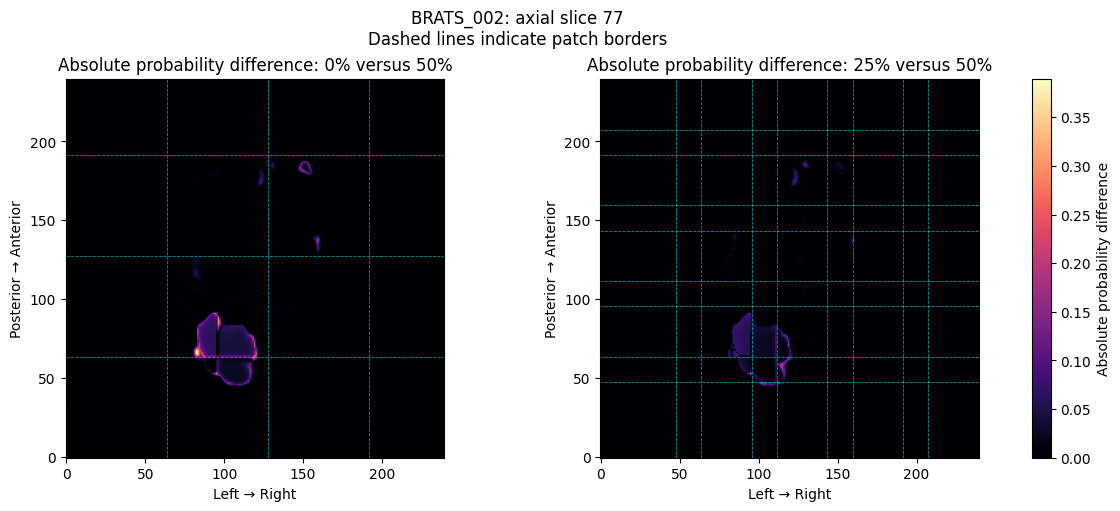

In [56]:
# Plotting probability differences at borders 
def patch_borders(length, patch, stride):
    steps = max(0, int(np.ceil((length - patch) / stride)))
    starts = np.arange(steps + 1) * stride
    borders = np.unique(np.concatenate([starts, starts + patch]))
    return borders[(borders > 0) & (borders < length)]


differences = [np.abs(example_probabilities[o] - example_probabilities[0.50]) for o in [0.0, 0.25]]
colour_limit = max(float(d.max()) for d in differences)
colour_limit = max(colour_limit, 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
aspect = example_spacing[1] / example_spacing[2]

for ax, overlap, difference in zip(axes, [0.0, 0.25], differences):
    plot = ax.imshow(difference, cmap='magma', origin='lower', vmin=0, vmax=colour_limit, aspect=aspect)

    stride_h = int(round(PATCH_SIZE[1] * (1 - overlap)))
    stride_w = int(round(PATCH_SIZE[2] * (1 - overlap)))

    for border in patch_borders(example_shape[1], PATCH_SIZE[1], stride_h):
        if border < difference.shape[0]:
            ax.axhline(border - 0.5, color='cyan', linestyle='--', linewidth=0.6, alpha=0.6)

    for border in patch_borders(example_shape[2], PATCH_SIZE[2], stride_w):
        if border < difference.shape[1]:
            ax.axvline(border - 0.5, color='cyan', linestyle='--', linewidth=0.6, alpha=0.6)

    ax.set_title(f'Absolute probability difference: {overlap:.0%} versus 50%')
    ax.set_xlabel('Left → Right')
    ax.set_ylabel('Posterior → Anterior')

fig.colorbar(plot, ax=axes, label='Absolute probability difference')
fig.suptitle(f'{example_case}: axial slice {middle_slice}\nDashed lines indicate patch borders')
save_figure('bonus2_probability_differences')

I compared 0%, 25% and 50% overlap using the same trained model, threshold and postprocessing rule. For 64³ patches, these settings correspond to strides of 64, 48 and 32 voxels. Overlapping probabilities were averaged with equal weights before thresholding, corresponding to constant blending (MONAI documentation).
Mean inference time was 5.43, 8.24 and 21.45 seconds per case for 0%, 25% and 50% overlap, respectively. Mean Dice increased from 0.7832 to 0.7876 to 0.7898, while mean HD95 decreased from 39.27 to 38.77 to 38.70 mm and mean absolute volume error decreased from 24.39 to 23.70 to 23.18 mL. Increasing overlap therefore produced modest improvements in these mean metrics. However, 50% overlap took approximately four times as long as 0% overlap, with a Dice increase of only 0.0067, showing diminishing improvements relative to the additional computation.
Overlap can help when predictions near patch edges are less reliable because the model has limited surrounding context. A voxel near one patch’s edge may appear closer to another patch’s centre, allowing averaging to reduce inconsistencies. However, overlap does not guarantee better accuracy and requires additional model evaluations.
The difference maps show where probabilities change relative to 50% overlap. Bright regions following patch borders would support sensitivity to patch placement, but probability differences alone do not establish which prediction is correct.
I treated this as a fixed stress test. Repeatedly inspecting test labels and selecting the best overlap would tune the pipeline to the test set and make its reported performance optimistically biased. Overlap should instead be chosen using validation evidence and fixed before final test evaluation.